# Extra — NER S5.2.5.5 / GPS compliance: unbalanced faults, sequence networks, and protection timing in a positive-sequence simulator

> **Standalone spin-off.** This notebook sits outside the Phase 0–7
> ladder. It adds **no new model code** to `smib/*`; everything new
> lives in this notebook. Prerequisite: `phase2_2_pss.ipynb` — we use
> the same operating point, the same 50 Hz system and the same
> GENROU + ST1A + PSS1A stack throughout.

**The problem.** The NER Generator Performance Standards make the
*single-line-to-ground* (1φg) fault the canonical disturbance a plant
must ride through — yet smib (and PSSE bulk-system dynamics) solve a
**positive-sequence-only** network that natively knows only the
balanced 3φ fault. Before any compliance claim can be made for a 1φg,
you need a translation layer between the asymmetric physical fault and
the positive-sequence model the stability tool actually solves. This
notebook builds that translation layer from first principles and runs
smib in *equivalent-positive-sequence* mode for every fault type.

Headline artefacts:

1. **Fault-severity ladder** (§8) — the same 150 ms bolted fault run as
   3φ, 2φg, LL and 1φg equivalents. Peak rotor swing drops monotonically
   (≈117° → 96° → 86° → 79°) and the 1φg critical clearing time is
   an order of magnitude longer than the 3φ one. This is *why* the
   headline 3φ studies of Phases 1–2.2 were always the conservative case.
2. **Dead-time-vs-stability chart** (§9) — three-pole auto-reclose on a
   double-circuit line: how long the dead time can be before reclosing
   returns the machine to an unrecoverable angle.
3. **Single-pole vs three-pole tripping** (§10) — for a 1φg on a radial
   single-circuit connection, single-pole tripping keeps a two-phase
   synchronising path and rides through an 800 ms dead time; three-pole
   tripping islands the machine within one swing.
4. **GPS compliance hooks** (§11) — the four clearance scenarios implied
   by NER S5.2.5.5(c) run end-to-end, checked against the S5.2.5.4
   voltage envelope and the S5.2.5.5A(d) active-power-recovery clock.

**Source discipline.** Regulatory and PSSE-manual statements in this
notebook are quoted from the primary sources in
`notebooks/extra_ner_s5255_plan/` (NER v248 Chapter 5, PSS/E-30 Program
Operation Manual chapter 7, AEMO Power System Model Guidelines v3.0,
AEMO Access Standard Assessment Guide 2019, Glover/Overbye/Sarma,
Anderson, Kundur). Statements that would need IEEE C37.104 / C37.113 or
CIGRE TB 326 — which were **not** provided — are marked **TODO** and
left unquantified rather than guessed. Study assumptions (zero-sequence
parameters) are declared in an assumption box in §5 and
sensitivity-swept.

## 1. Why this notebook exists — and one correction to the plan

**What the rules actually say (v248).** The planning document for this
notebook was written from memory and described "S5.2.5.5" as the
*response to disturbances* clause. The current consolidated rules are
structured differently, and the notebook follows the rules as they
stand. In **NER version 248, Chapter 5, Schedule 5.2**:

> **S5.2.5.5 Disturbance ride-through capability** — the clause that
> defines *which* disturbances (fault types × clearance times ×
> multiple-disturbance sequences) a schedule 5.2 plant must remain in
> **continuous uninterrupted operation** (CUO) through.
>
> **S5.2.5.5A Responses to disturbances following contingency events**
> — the clause that defines *how* the plant must behave while riding
> through (reactive current injection, active power recovery).

(The 2019 AEMO *Access Standard Assessment Guide* §3.5 still carries the
old title "[Clause S5.2.5.5] Generating system response to disturbances
following contingency events" — the clause was subsequently
restructured into the S5.2.5.5 / S5.2.5.5A pair quoted in §11.)

**The canonical disturbance is unbalanced.** S5.2.5.5(c) (quoted in
full in §11) lists, beyond credible contingency events: a 3φ fault
cleared by primary protection, and **two-phase-to-ground / phase-to-phase
/ phase-to-ground faults cleared in breaker-fail time**. The minimum
access standard S5.2.5.5(k)(2) is *entirely* about unbalanced faults —
under it a plant need not ride through any 3φ fault at all. So the
fault types this notebook studies are exactly the ones the GPS turns on.

**Why a positive-sequence tool is still the right instrument.** AEMO's
*Power System Model Guidelines* (v3.0, 25 September 2025), §6.2.2
"Balanced and unbalanced Disturbances":

> "Positive-sequence simulation models are expected to meet the model
> accuracy requirements specified in Section 6.2.1 for balanced
> Disturbances. For comparison of the response to different types of
> unbalanced faults, a positive-sequence model can still be used if it
> can achieve the required accuracy requirements. When a
> positive-sequence model fails to meet the accuracy requirements by a
> material margin, the use of EMT-type or three-phase RMS simulation
> models is permissible …" — and footnote 57: "When using
> positive-sequence type models for simulation of unbalanced
> Disturbances, the Applicant must provide information on any possible
> changes in the model parameters to simulate various types of faults."

That footnote *is* this notebook: the "changes in the model parameters
to simulate various types of faults" are precisely the equivalent fault
impedances we derive in §6–§8.

**Roadmap.** §4 derives symmetrical components. §5 builds the three
sequence Thevenins of our SMIB. §6 wires them together per fault type
and cross-checks against Glover and against a worked PSS/E manual
example. §7 explains why delta windings make the zero-sequence network
short and judgement-laden. §8 turns each unbalanced fault into the
equivalent positive-sequence shunt PSSE uses, and runs smib with it.
§9–§10 add the protection timing layer (reclose, breaker fail,
single-pole tripping). §11 closes the loop back to the GPS clauses, and
§12 is honest about what this analysis cannot see.

## 2. Imports

Same bootstrap as every phase notebook, plus `cmath` for complex
phasor work. No new smib modules — this notebook deliberately uses
only what Phase 2.2 already shipped.

In [1]:
# Bootstrap so the smib package is importable from notebooks/.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here.parent if _here.name == 'notebooks' else _here
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import math, cmath
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import SVG, display

from smib.models import GENROU
from smib.models.st1a import ST1A
from smib.models.pss1a import PSS1A
from smib.network import Network
from smib.powerflow import two_bus_pf, ybus_2bus
from smib.scenarios import three_phase_fault_schedule
from smib.simulator import run_smib_genrou_avr_pss
from smib.plotting import plot_sld, validate_ride_through

# House colour scheme (Phase 1 §10 onwards).
C_POS, C_NEG, C_ZER = '#1565C0', '#EF6C00', '#2E7D32'   # sequence networks
C_BLUE, C_GREEN, C_RED, C_ORANGE, C_PURPLE = (
    '#1565C0', '#2E7D32', '#C62828', '#EF6C00', '#6A1B9A')
FAULT_SHADE = '#FFCDD2'

## 3. Operating point — identical to Phases 2.0/2.1/2.2

Same two-bus system, same dispatch. The generator bus exports
$S = P + jQ = 0.8 + j0.2$ pu into a purely inductive line
$X_{\text{line}} = 0.5$ pu terminated by the infinite bus
$\bar V_\infty = 1.0\angle 0°$. The Newton–Raphson power flow solves
the PQ-bus mismatch equations

$$P_1 = |V_1||V_\infty|\,B\,\sin\theta_1,\qquad
  Q_1 = |V_1|^2 B - |V_1||V_\infty|\,B\,\cos\theta_1,\qquad B = 1/X_{\text{line}}$$

for $|V_1|, \theta_1$. Per pedagogy rule 2 we run it `verbose=True` so
every NR iteration (state, mismatch, update) prints; per rule 5 the
converged operating point is rendered as a single-line diagram.

One physical framing matters for everything below: in this notebook the
generator bus is read as the **HV connection point** — the machine
reactances and the (implicit) GSU sit behind it, the line is the
transmission connection to the wider grid. §5 makes the GSU explicit
where it matters (the zero-sequence network).

In [2]:
P, Q = 0.8, 0.2
R_line, X_line = 0.0, 0.5
V_inf = 1.0 + 0j

V1, iters = two_bus_pf(P, Q, abs(V_inf), 0.0, R_line, X_line,
                       bus_type='PQ', verbose=True)
S = complex(P, Q)
print(f'\nPF converged in {iters} iters: '
      f'V1 = {abs(V1):.4f} pu /_ {math.degrees(np.angle(V1)):.3f} deg')

fig = plot_sld(V_gen=V1, S_gen=S, V_inf=V_inf,
               R_line=R_line, X_line=X_line,
               gen_label='GENROU+ST1A+PSS1A',
               title='SMIB single-line diagram (extra_ner_s5255, post-LF)')
fig.show()

iter       |V1|   angle deg        mis P        mis Q    |mismatch|
   0   1.000000      0.0000    8.000e-01    2.000e-01     8.000e-01
   1   1.100000     22.9183   -5.672e-02   -1.937e-01     1.937e-01
   2   1.023860     22.9913    1.792e-04   -1.152e-02     1.152e-02
   3   1.017829     23.1399    3.149e-05   -6.683e-05     6.683e-05
   4   1.017787     23.1419    3.173e-09   -3.554e-09     3.554e-09
   5   1.017787     23.1419    1.110e-16    2.776e-17     1.110e-16
>>> Converged in 5 iterations to |mismatch| < 1e-10

PF converged in 5 iters: V1 = 1.0178 pu /_ 23.142 deg


## 4. Symmetrical components refresher (Fortescue)

Any unbalanced set of three phasors $(\bar V_a, \bar V_b, \bar V_c)$
decomposes **exactly** into three balanced sets — this is Fortescue's
1918 result, and it is an identity, not an approximation. Define the
rotation operator

$$a = e^{j2\pi/3} = 1\angle 120°, \qquad 1 + a + a^2 = 0 .$$

The three balanced sets are: **zero sequence** (three equal phasors,
$\bar V_{a0}=\bar V_{b0}=\bar V_{c0}$), **positive sequence** (abc
rotation: $\bar V_{b1} = a^2 \bar V_{a1}$, $\bar V_{c1} = a\bar V_{a1}$)
and **negative sequence** (acb rotation: $\bar V_{b2} = a\bar V_{a2}$,
$\bar V_{c2} = a^2\bar V_{a2}$). Stacking the phase-a representatives
$\bar V_0, \bar V_1, \bar V_2$:

$$\begin{bmatrix}\bar V_a\\ \bar V_b\\ \bar V_c\end{bmatrix}
 = \underbrace{\begin{bmatrix}1&1&1\\ 1&a^2&a\\ 1&a&a^2\end{bmatrix}}_{\mathbf A}
   \begin{bmatrix}\bar V_0\\ \bar V_1\\ \bar V_2\end{bmatrix},
\qquad
\mathbf A^{-1} = \frac13\begin{bmatrix}1&1&1\\ 1&a&a^2\\ 1&a^2&a\end{bmatrix}
 = \frac13\,\mathbf A^{*}.$$

That inverse is the whole trick: $\mathbf A^H\mathbf A = 3\,\mathbf I$,
i.e. the columns of $\mathbf A$ are **orthogonal**. Orthogonality is
what decouples the sequence networks of any *symmetric* three-phase
element — transform the phase-impedance matrix
$\mathbf Z_{abc}$ of a balanced element and
$\mathbf A^{-1}\mathbf Z_{abc}\mathbf A$ comes out diagonal
(Glover/Overbye/Sarma derive this as eq. (8.2.13): for a balanced Y
load, $V_0 = (Z_Y + 3Z_n)I_0$, $V_1 = Z_Y I_1$, $V_2 = Z_Y I_2$ — three
independent single-phase circuits). Faults are the *one place* the
three networks touch, which is why fault analysis in sequence
coordinates is so clean.

The code below builds $\mathbf A$, verifies the inverse identity to
machine precision, then decomposes a worked example: a phase-a voltage
sag ($\bar V_a = 0.25\angle 0°$, healthy $\bar V_b, \bar V_c$) — the
kind of unbalance a nearby 1φg fault produces.

In [3]:
# --- Build the Fortescue matrix and verify its inverse identity. ---
a = cmath.exp(2j * math.pi / 3)
A = np.array([[1, 1, 1],
              [1, a**2, a],
              [1, a, a**2]], dtype=complex)
A_inv_manual = (1/3) * np.conj(A)           # claim: A^-1 = (1/3) A*
assert np.allclose(A_inv_manual @ A, np.eye(3), atol=1e-14)
assert np.allclose(np.linalg.inv(A), A_inv_manual, atol=1e-14)
print('A^-1 == (1/3) A*  verified to machine precision')
print('columns orthogonal: A^H A =\n', np.round(np.conj(A.T) @ A, 12))

# --- Worked example: phase-a sag (what a close-in 1phg looks like). ---
Vabc = np.array([0.25 * cmath.exp(0j),
                 1.00 * cmath.exp(-2j*math.pi/3),
                 1.00 * cmath.exp(+2j*math.pi/3)])
V012 = A_inv_manual @ Vabc
labels = ['V0 (zero)', 'V1 (positive)', 'V2 (negative)']
print('\nUnbalanced set  Va=0.25/_0, Vb=1/_-120, Vc=1/_+120  decomposes to:')
for lbl, v in zip(labels, V012):
    print(f'  {lbl:14s} = {abs(v):.4f} pu /_ {math.degrees(cmath.phase(v)):8.2f} deg')

# Reconstruct each balanced set as full abc phasors and verify the sum.
sets = {
    'unbalanced abc': Vabc,
    'zero seq':      np.array([V012[0]]*3),
    'positive seq':  np.array([V012[1], a**2*V012[1], a*V012[1]]),
    'negative seq':  np.array([V012[2], a*V012[2], a**2*V012[2]]),
}
recon = sets['zero seq'] + sets['positive seq'] + sets['negative seq']
err = np.abs(recon - Vabc).max()
print(f'\nreconstruction max |error| = {err:.2e}  (must be ~1e-16)')
assert err < 1e-14

# --- Phasor plot: the unbalanced set and its three balanced children. ---
fig = make_subplots(rows=1, cols=4, subplot_titles=list(sets.keys()))
phase_colors = [C_BLUE, C_RED, C_GREEN]
for col, (name, vs) in enumerate(sets.items(), start=1):
    for ph, v in enumerate(vs):
        fig.add_trace(go.Scatter(
            x=[0, v.real], y=[0, v.imag], mode='lines+markers',
            marker=dict(size=[0, 8]), line=dict(color=phase_colors[ph], width=2),
            name='abc'[ph], legendgroup='abc'[ph], showlegend=(col == 1)),
            row=1, col=col)
    fig.update_xaxes(range=[-1.2, 1.2], row=1, col=col,
                     zeroline=True, scaleanchor=f'y{col if col>1 else ""}')
    fig.update_yaxes(range=[-1.2, 1.2], row=1, col=col, zeroline=True)
fig.update_layout(height=320, width=1150,
                  title='Fortescue decomposition of a phase-a sag '
                        '(blue=a, red=b, green=c)')
fig.show()

A^-1 == (1/3) A*  verified to machine precision
columns orthogonal: A^H A =
 [[ 3.+0.j -0.+0.j -0.+0.j]
 [-0.-0.j  3.+0.j  0.-0.j]
 [-0.-0.j  0.-0.j  3.+0.j]]

Unbalanced set  Va=0.25/_0, Vb=1/_-120, Vc=1/_+120  decomposes to:
  V0 (zero)      = 0.2500 pu /_   180.00 deg
  V1 (positive)  = 0.7500 pu /_     0.00 deg
  V2 (negative)  = 0.2500 pu /_  -180.00 deg

reconstruction max |error| = 3.33e-16  (must be ~1e-16)


**Reading the plot.** The sagged phase-a set (left) is the sum,
phasor by phasor, of the three balanced sets to its right. Notice what
the decomposition did with a *single-phase* dip of depth
$\Delta = 0.75$ pu: it split it **evenly three ways** —
$\bar V_1 = 1 - \Delta/3 = 0.75$, $\bar V_0 = \bar V_2 = -\Delta/3 =
0.25\angle 180°$. That even split is the orthogonal projection at work,
and it is the first hint of the headline result: a 1φg fault that
*kills* one phase only drags the positive-sequence voltage — the only
voltage a synchronous machine's torque production cares about at
fundamental frequency — down by a third of the phase-a depth. The
machine, and the positive-sequence simulator, ride through something
much shallower than the oscillography would suggest.

## 5. Sequence networks of the SMIB

A fault calculation needs the Thevenin equivalent of each sequence
network **as seen from the fault bus** (our HV connection-point bus).

**Positive sequence** — this is the network smib already solves every
timestep: the transient EMF $\bar E'$ behind $X'_d$ ($= 0.30$ pu,
Kundur Table 4.2 via `GENROU` defaults), the line $X_{\text{line}} =
0.5$ pu, the infinite bus (zero internal impedance). With the source
zeroed, the Thevenin impedance at the fault bus is the machine and line
branches in parallel:

$$Z_{1,\text{th}} = jX'_d \,\|\, jX_{\text{line}}.$$

**Negative sequence** — same topology, but *no source*: a synchronous
machine generates only positive-sequence EMF, so in the negative
network every source is zeroed by construction. The machine's
negative-sequence impedance is set by the *sub-transient* flux paths —
negative-sequence stator current produces a backward-rotating MMF that
the rotor sees at $2f_0$, so both damper circuits stay engaged. Kundur
§13.4.2 (p. 877–880) derives the result and states it directly: *"the
negative-sequence reactance $X_2$ is equal to the mean between the d-
and q-axis subtransient reactances"* — his eq. (13.78):

$$X_2 = \tfrac12\!\left(X''_d + X''_q\right).$$

(Saliency makes the exact value depend on whether sinusoidal currents
are circulated or sinusoidal voltages applied — Kundur's caveat on the
same page; with the PSSE GENROU convention $X''_q = X''_d$ the
distinction vanishes.)

Our 4-state GENROU deliberately carries no sub-transient states
(Phase 2.0b deferral), but the *parameters* exist in this repo's PSSE
benchmark: `psse/phase2_0/smib_phase2_0.dyr` has $X''_d = 0.23$ with
the PSSE GENROU convention $X''_q = X''_d$, so $X_2 = 0.23$ pu. For the
line, $X_2 = X_1$ (a static element has no rotation to break the
symmetry).

$$Z_{2,\text{th}} = jX_2 \,\|\, jX_{\text{line}}.$$

**Zero sequence** — this is where the engineering judgement lives,
because the zero-sequence network is set by **grounding and transformer
winding connections**, not by nameplate impedances. Our assumed physical
topology (drawn in §7): machine → **Δ–Yg GSU** (delta on the machine
side, grounded wye on the HV side — the standard generator step-up
arrangement) → HV bus → transmission line → grounded system. The delta
winding blocks any zero-sequence exchange with the stator (§7 walks
through why), but the grounded-wye HV winding provides a zero-sequence
path to ground *through the transformer impedance*. So

$$Z_{0,\text{th}} = jX_{0,\text{GSU}} \,\|\, jX_{0,\text{line}}.$$

> **Assumption box (study parameters, not sourced facts).**
>
> | quantity | value | status |
> |---|---|---|
> | $X_2$ machine | $0.23$ pu $=(X''_d+X''_q)/2$ | from `psse/phase2_0/smib_phase2_0.dyr` (Kundur Table 4.2) |
> | $X_{0,\text{GSU}}$ | $0.15$ pu | **assumed** — typical GSU leakage order; swept below |
> | $X_{0,\text{line}}/X_{1,\text{line}}$ | $3.0$ | **assumed** — overhead-line order of magnitude; swept below |
> | GSU connection | Δ–Yg | **assumed** standard practice; consequences derived in §7 |
> | infinite bus grounding | solidly grounded | modelling choice consistent with "infinite" |
>
> The sweep in the next cell shows why sloppy zero-sequence line data is
> survivable here: the GSU ground tie sits in parallel and dominates.

In [4]:
def par(*zs):
    '''Parallel combination of impedances (transparent one-liner).'''
    return 1.0 / sum(1.0/z for z in zs)

Xd_p   = 0.30          # GENROU default, Kundur Table 4.2
X2_m   = 0.23          # (X"d + X"q)/2 with X"q = X"d (PSSE GENROU, .dyr file)
X0_gsu = 0.15          # ASSUMED study parameter (see box above)
k0     = 3.0           # ASSUMED X0/X1 line ratio (swept below)
X0_line = k0 * X_line

Z1_th = par(1j*Xd_p, 1j*X_line)
Z2_th = par(1j*X2_m, 1j*X_line)
Z0_th = par(1j*X0_gsu, 1j*X0_line)

print('Sequence Thevenin impedances at the fault (HV) bus:')
print(f'  Z1_th = jX\'d || jX_line   = j{Xd_p} || j{X_line}  = {Z1_th:.5f}')
print(f'  Z2_th = jX2  || jX_line   = j{X2_m} || j{X_line}  = {Z2_th:.5f}')
print(f'  Z0_th = jX0gsu || jX0line = j{X0_gsu} || j{X0_line} = {Z0_th:.5f}')

# Sensitivity: how much does the sloppy X0_line assumption matter?
print('\nSensitivity of Z0_th to the assumed X0/X1 line ratio:')
for kk in (2.0, 2.5, 3.0, 3.5, 4.0):
    z = par(1j*X0_gsu, 1j*kk*X_line)
    print(f'  X0/X1 = {kk:3.1f}  ->  Z0_th = {z.imag:.5f}j   '
          f'({(z.imag/Z0_th.imag - 1)*100:+5.1f}% vs base)')
print('\nThe GSU ground tie (j0.15) is the smaller parallel branch, so it')
print('pins Z0_th: a +/-33% change in line X0 moves Z0_th by only ~3%.')

Sequence Thevenin impedances at the fault (HV) bus:
  Z1_th = jX'd || jX_line   = j0.3 || j0.5  = -0.00000+0.18750j
  Z2_th = jX2  || jX_line   = j0.23 || j0.5  = -0.00000+0.15753j
  Z0_th = jX0gsu || jX0line = j0.15 || j1.5 = -0.00000+0.13636j

Sensitivity of Z0_th to the assumed X0/X1 line ratio:
  X0/X1 = 2.0  ->  Z0_th = 0.13043j   ( -4.3% vs base)
  X0/X1 = 2.5  ->  Z0_th = 0.13393j   ( -1.8% vs base)
  X0/X1 = 3.0  ->  Z0_th = 0.13636j   ( +0.0% vs base)
  X0/X1 = 3.5  ->  Z0_th = 0.13816j   ( +1.3% vs base)
  X0/X1 = 4.0  ->  Z0_th = 0.13953j   ( +2.3% vs base)

The GSU ground tie (j0.15) is the smaller parallel branch, so it
pins Z0_th: a +/-33% change in line X0 moves Z0_th by only ~3%.


## 6. Fault-type connection diagrams

Every shunt fault is a set of **boundary conditions at the fault point**
in phase coordinates; transformed by $\mathbf A^{-1}$ they become rules
for wiring the three sequence Thevenins together. We derive the 1φg
case in full; the others follow the identical recipe. Cross-checks run
against **both** canonical texts: Glover §9.2–§9.4 and Anderson
§3.1–§3.3 (SLG: Anderson eqs. (3.1)–(3.4) and Fig. 3.4; LL: §3.2,
Fig. 3.11; 2LG: §3.3, eqs. (3.12)–(3.20)) — the two books set up the
same boundary conditions and land on the same connections, Kundur
Figs. 13.21–13.23 likewise.

**1φg on phase a through $Z_f$.** Phase-domain boundary conditions:

$$I_b = I_c = 0, \qquad V_{ag} = Z_f I_a .$$

Transform the currents: with $I_b = I_c = 0$,
$I_{0,1,2} = \tfrac13(I_a + \{1,a,a^2\}\cdot 0 + \dots) = \tfrac13 I_a$, i.e.

$$\boxed{I_0 = I_1 = I_2} \qquad \text{(Glover eq. 9.2.5)}$$

— equal currents through all three networks means they are **in
series**. Transform the voltage condition: $V_{ag} = V_0+V_1+V_2$ and
$I_a = 3I_1$, so

$$V_0 + V_1 + V_2 = 3Z_f\, I_1 \qquad \text{(Glover eq. 9.2.6)}$$

— the series loop closes through $3Z_f$. Solving the loop:

$$I_1 = \frac{V_F}{Z_1 + Z_2 + Z_0 + 3Z_f} \quad\text{(9.2.7)},\qquad
  I_a = 3I_1 \quad\text{(9.2.8)} .$$

(Anderson's §3.1 derivation is word-for-word the same physics: his
(3.1)–(3.2) are the boundary conditions, his (3.3) gives
$I_{a0}=I_{a1}=I_{a2}=I_a/3$, his (3.4) is
$V_{a0}+V_{a1}+V_{a2} = 3Z_f I_{a1}$, and his Fig. 3.4 is the series
connection drawn below.)

**The other three topologies** (derivations in Glover §9.3–§9.4, same
boundary-condition recipe):

| fault | sequence wiring | $I_1$ |
|---|---|---|
| 3φ | positive only, $Z_f$ closes it | $V_F/(Z_1 + Z_f)$ |
| 1φg | all three **in series** with $3Z_f$ | $V_F/(Z_1+Z_2+Z_0+3Z_f)$ (9.2.7) |
| LL | positive ∥ negative via $Z_f$, zero open | $V_F/(Z_1+Z_2+Z_f)$ (9.3.10) |
| 2φg | positive in series with $Z_2\,\|\,(Z_0+3Z_f)$ | $V_F/\!\left(Z_1 + \frac{Z_2(Z_0+3Z_f)}{Z_2+Z_0+3Z_f}\right)$ (9.4.12) |

Note the LL row: the zero-sequence network is **open** ($I_0 = 0$,
eq. 9.3.7) because with no ground involved there is no path for the
in-phase current set. That is the structural reason ungrounded faults
never excite zero sequence — and the dual of §7's delta-winding story.

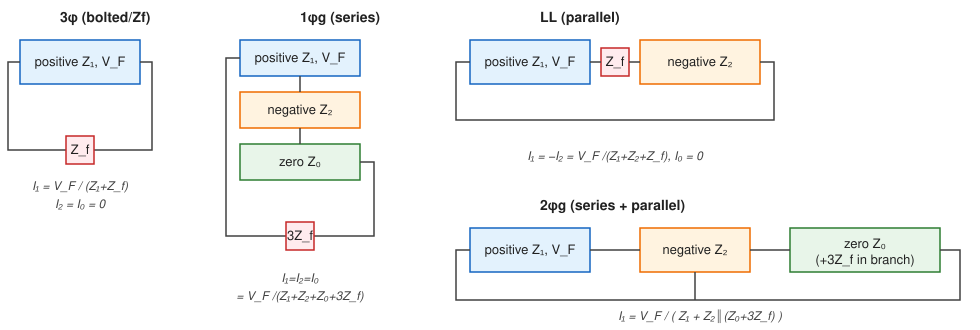

In [5]:
display(SVG(filename='figs/seq_fault_connections.svg'))

In [6]:
# --- Transparent implementations of the four connection topologies. ---
def fault_seq_currents(kind, VF, Z1, Z2, Z0, Zf=0j, Zg=0j):
    '''Return (I1, I2, I0) at the fault point for the given fault type.
    Direct transcription of the connection diagrams / Glover ch. 9.
    Zg: additional ground impedance in the zero-seq branch (2phg).'''
    if kind == '3ph':
        I1 = VF / (Z1 + Zf);                 return I1, 0j, 0j
    if kind == '1phg':
        I1 = VF / (Z1 + Z2 + Z0 + 3*Zf);     return I1, I1, I1
    if kind == 'LL':
        I1 = VF / (Z1 + Z2 + Zf);            return I1, -I1, 0j
    if kind == '2phg':
        Zp = (Z2 * (Z0 + 3*Zf + 3*Zg)) / (Z2 + Z0 + 3*Zf + 3*Zg)
        I1 = VF / (Z1 + Zp)
        V1 = VF - Z1 * I1                    # sequence voltage at fault bus
        I2 = -V1 / Z2                        # current divider (Glover 9.4.13)
        I0 = -V1 / (Z0 + 3*Zf + 3*Zg)        # (Glover 9.4.14)
        return I1, I2, I0
    raise ValueError(kind)

VF = abs(V1)        # pre-fault voltage magnitude at the fault bus
print(f'Pre-fault |V| at fault bus (from the load flow): VF = {VF:.4f} pu\n')
rows = []
for kind in ('3ph', '1phg', 'LL', '2phg'):
    I1, I2, I0 = fault_seq_currents(kind, VF, Z1_th, Z2_th, Z0_th)
    V1f = VF - Z1_th * I1                       # pos-seq V at bus during fault
    Ia  = I1 + I2 + I0                          # phase-a current
    rows.append((kind, I1, I2, I0, V1f, Ia))
    print(f'{kind:5s}: |I1|={abs(I1):6.3f}  |I2|={abs(I2):6.3f}  '
          f'|3I0|={3*abs(I0):6.3f}  |V1|during={abs(V1f):5.3f}  |Ia|={abs(Ia):6.3f}')

print('\nNote |Ia| ~ 0 for LL and 2phg: the convention (Glover ch. 9) puts')
print('those faults on phases b and c, so phase a is the *healthy* phase;')
print('the faulted-phase current is e.g. |Ib| = |a^2*I1 + a*I2 + I0|.')

# --- Cross-check 1: identical-algebra check against the Glover formulas ---
I1_g = VF / (Z1_th + Z2_th + Z0_th)             # 9.2.7, bolted
assert abs(fault_seq_currents('1phg', VF, Z1_th, Z2_th, Z0_th)[0] - I1_g) < 1e-14
I1_ll = VF / (Z1_th + Z2_th)                    # 9.3.10, bolted
assert abs(fault_seq_currents('LL', VF, Z1_th, Z2_th, Z0_th)[0] - I1_ll) < 1e-14
print('\nGlover (9.2.7) and (9.3.10) closed forms reproduced exactly.')

# --- Cross-check 2: reproduce the PSS/E-30 POM worked example ---------
# Fig. 7-45 (L-G fault at bus 300 of the manual's single-phase example
# network, "Working with a Two-Wire System"): only Z1 and Z0 appear.
# Manual values: Z1 = 0.28804+j1.07742, Z0 = 0.00127+j0.11696,
# Voc = 1.009; manual results: I0 = I1 = 0.8211 /_ -76.4 deg,
# phase current 1.6417, POSITIVE SEQUENCE EQUIVALENT FAULT ADMITTANCE
# = 0.0927 - j8.5492.
Z1p = 0.28804 + 1.07742j
Z0p = 0.00127 + 0.11696j
Voc = 1.009
I1p = Voc / (Z1p + Z0p)                  # manual: I0 = I1 = Voc/(Z0+Z1)
V1p = Voc - Z1p * I1p                    # pos-seq voltage at the bus
Yeq = I1p / V1p                          # PSSE's equivalent fault admittance
print('\nPSS/E-30 POM Figure 7-45 reproduction:')
print(f'  I1  = {abs(I1p):.4f} /_ {math.degrees(cmath.phase(I1p)):.1f} deg '
      f'  (manual: 0.8211 /_ -76.4)')
print(f'  Ia  = {abs(2*I1p):.4f}                (manual sum-of-contributions: 1.6417)')
print(f'  Yeq = {Yeq.real:.4f} {Yeq.imag:+.4f}j   (manual: 0.0927 -8.5492j)')
assert abs(abs(I1p) - 0.8211) < 5e-4
assert abs(Yeq - (0.0927 - 8.5492j)) < 5e-3
print('  PASS — our sequence algebra reproduces the PSSE manual numbers.')

Pre-fault |V| at fault bus (from the load flow): VF = 1.0178 pu

3ph  : |I1|= 5.428  |I2|= 0.000  |3I0|= 0.000  |V1|during=0.000  |Ia|= 5.428
1phg : |I1|= 2.114  |I2|= 2.114  |3I0|= 6.343  |V1|during=0.621  |Ia|= 6.343
LL   : |I1|= 2.950  |I2|= 2.950  |3I0|= 0.000  |V1|during=0.465  |Ia|= 0.000
2phg : |I1|= 3.906  |I2|= 1.812  |3I0|= 6.280  |V1|during=0.285  |Ia|= 0.000

Note |Ia| ~ 0 for LL and 2phg: the convention (Glover ch. 9) puts
those faults on phases b and c, so phase a is the *healthy* phase;
the faulted-phase current is e.g. |Ib| = |a^2*I1 + a*I2 + I0|.

Glover (9.2.7) and (9.3.10) closed forms reproduced exactly.

PSS/E-30 POM Figure 7-45 reproduction:
  I1  = 0.8210 /_ -76.4 deg   (manual: 0.8211 /_ -76.4)
  Ia  = 1.6421                (manual sum-of-contributions: 1.6417)
  Yeq = 0.0928 -8.5489j   (manual: 0.0927 -8.5492j)
  PASS — our sequence algebra reproduces the PSSE manual numbers.


**What the table is telling us, physically.** Walk down the
$|V_1|$-during-fault column for *bolted* faults at our HV bus: 3φ
drives the positive-sequence voltage to zero by definition; 2φg leaves
$\approx 0.25$ pu; LL $\approx 0.42$ pu; 1φg $\approx 0.57$ pu. The
extra sequence impedances in the fault loop ($Z_2$, $Z_0$) act exactly
like external fault impedance as far as the positive-sequence network
is concerned. Since the machine's accelerating power during the fault
is $P_m - P_e$ with $P_e \propto |V_1|$-ish (the §8 runs make this
precise), the fault-severity ladder of the headline plot is already
visible right here, before any dynamics are run.

The PSSE cross-check matters for a different reason: it certifies that
the quantity PSSE prints as *"POSITIVE SEQUENCE EQUIVALENT FAULT
ADMITTANCE"* is computable from our Thevenin table alone — which is
what lets §8 drive smib with it.

## 7. Why delta windings block zero-sequence current externally

This deserves a careful walk-through because it is the single most
consequential piece of *topology* in unbalanced fault analysis.

**Step 1 — zero-sequence current needs a return path.** Zero-sequence
current is *in phase on all three phases*: $\bar I_{a0} = \bar I_{b0} =
\bar I_{c0} = \bar I_0$. At any node, the three phase conductors
together carry $3\bar I_0$ — which, unlike balanced current, does
**not** cancel. It must return somewhere: through a neutral wire, a
grounded neutral, or the earth itself. **No ground path ⇒ no
zero-sequence current.** (Glover eq. 8.2.13 carries this as the $3Z_n$
term: a Y connection grounded through $Z_n$ puts $3Z_n$ in the
zero-sequence circuit; ungrounded Y means $Z_n \to \infty$ — open.)

**Step 2 — a delta winding has no external neutral, but a perfectly
good internal loop.** Apply zero-sequence MMF to the three legs of a
transformer with a delta winding. The three induced leg EMFs are equal
and in phase, and around the closed delta they *add*:
$3\bar E_0$ drives a **circulating current inside the delta**. That
circulating current is real (it is why the delta acts as a
zero-sequence flux suppressor) — but from the *terminals* of the delta,
line currents are differences of adjacent leg currents:
$\bar I_{\text{line}} = \bar I_{\text{leg},x} - \bar I_{\text{leg},y} = 0$
when all legs carry the same $\bar I_0$. So: **zero-sequence current
circulates inside the delta and none leaves it.**

**Step 3 — the equivalent-circuit translation.** In the per-phase
zero-sequence equivalent of a Δ–Yg transformer: the grounded-wye side
connects to the network through the transformer impedance **to ground**;
the delta side is an **open circuit** (with the closed-delta circulating
path shown as the impedance leg to the internal node). Any Δ–Y
transformer between the fault and a source is therefore a
**zero-sequence wall**. Kundur §13.4.4 (p. 884–885) states both halves
in one breath: *"the effective zero-sequence impedance as seen from the
primary side is $Z_p + 3Z_n$ … Since a Δ-connected circuit provides no
path for zero-sequence currents flowing in the line, the impedance as
seen from the secondary side is infinite."* (And for ungrounded Y on
either side: *"zero-sequence currents cannot flow in the windings on
either side"* — the case (iii) bar in the chart below.)

**Step 4 — the practical consequence for smib.** Our GSU is Δ
(machine) – Yg (HV). For a 1φg on the HV side: the HV grounded wye
gives the fault a zero-sequence path *through the GSU to ground* — but
the machine stator, behind the delta, **never carries any zero-sequence
current at all**. smib's machine model does not need a zero-sequence
representation for HV-side faults; only the zero-sequence *network*
(GSU ground tie ∥ line) matters, and it already lives in $Z_{0,\text{th}}$.

The PSS/E manual's two-wire example makes the limiting case vivid
(POM Fig. 7-46): a single ground connection with *no other* ground path
in the subsystem yields **zero fault current** for an L-G fault — "no
zero-sequence ground path ⇒ no 1φg fault current" taken to its
extreme. The cell below reproduces that spectrum on our network.

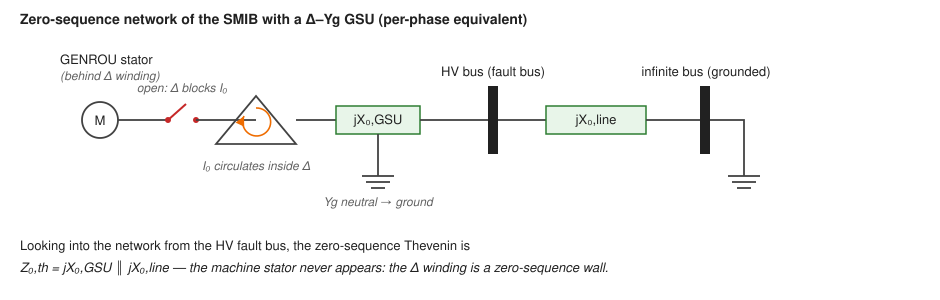

In [7]:
display(SVG(filename='figs/delta_zero_seq_wall.svg'))

In [8]:
# --- Grounding topology spectrum for the bolted 1phg at the HV bus ---
# (i)  base: D-Yg GSU ground tie in parallel with the grounded line
# (ii) GSU ungrounded (e.g. D-D, or Yg winding lost): line path only
# (iii) no ground path anywhere: Z0 -> inf, the PSSE Fig 7-46 case
cases = {
    'D-Yg GSU + grounded line (base)': par(1j*X0_gsu, 1j*X0_line),
    'GSU ungrounded -> line only':     1j*X0_line,
    'no ground path at all':           None,            # Z0 = infinity
}
print(f'{"zero-seq topology":35s} {"Z0_th":>12s} {"|I1| 1phg":>10s} {"|V1| during":>12s}')
bars_x, bars_i, bars_v = [], [], []
for name, Z0c in cases.items():
    if Z0c is None:
        I1c, V1c = 0j, complex(VF)       # open loop: no current, no sag
        z0s = 'open'
    else:
        I1c, _, _ = fault_seq_currents('1phg', VF, Z1_th, Z2_th, Z0c)
        V1c = VF - Z1_th * I1c
        z0s = f'{Z0c.imag:.4f}j'
    print(f'{name:35s} {z0s:>12s} {abs(I1c):10.3f} {abs(V1c):12.3f}')
    bars_x.append(name); bars_i.append(abs(I1c)); bars_v.append(abs(V1c))

# Where does the ground current go in the base case?  Current divider
# between the GSU neutral and the line zero-sequence path:
I1b, _, I0b = fault_seq_currents('1phg', VF, Z1_th, Z2_th, Z0_th)
V0b = -Z0_th * I0b                       # zero-seq voltage at the bus
I0_gsu  = -V0b / (1j*X0_gsu)
I0_line = -V0b / (1j*X0_line)
print(f'\nBase case 3I0 = {3*abs(I0b):.3f} pu splits: '
      f'GSU neutral {abs(I0_gsu)/abs(I0b)*100:.1f}% , line {abs(I0_line)/abs(I0b)*100:.1f}%')
print('Machine stator share: 0.0% — the delta wall, by construction.')

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    '|I1| at fault (pu)', '|V1| at bus during fault (pu)'])
fig.add_trace(go.Bar(x=bars_x, y=bars_i, marker_color=C_ZER), row=1, col=1)
fig.add_trace(go.Bar(x=bars_x, y=bars_v, marker_color=C_BLUE), row=1, col=2)
fig.update_layout(height=360, width=1000, showlegend=False,
                  title='Bolted 1phg vs zero-sequence grounding topology '
                        '(rightmost = PSSE Fig 7-46 limiting case)')
fig.show()

zero-seq topology                          Z0_th  |I1| 1phg  |V1| during
D-Yg GSU + grounded line (base)          0.1364j      2.114        0.621
GSU ungrounded -> line only              1.5000j      0.552        0.914
no ground path at all                       open      0.000        1.018

Base case 3I0 = 6.343 pu splits: GSU neutral 90.9% , line 9.1%
Machine stator share: 0.0% — the delta wall, by construction.


**Reading the bars.** Removing the GSU ground tie stiffens the
zero-sequence loop ($Z_0$: $0.136 \to 1.5$ pu) so the same 1φg draws
less than half the sequence current and barely dents $|V_1|$; removing
the last ground path kills the fault current entirely — an L-G "fault"
on a fully ungrounded subsystem just shifts the neutral (the PSSE
manual's Fig. 7-46 case, where the c-phase voltage rises to 1.99 pu of
phase-to-ground base while the fault current is exactly zero). Two
takeaways carry forward: **(1)** zero-sequence data you assume *matters
less than the topology you assert* — be right about winding connections
and grounding before polishing impedances; **(2)** the bolted-1φg severity
used in the rest of this notebook is, if anything, *conservative* for
our assumed topology, since every de-grounding variation makes the
fault milder.

## 8. How PSSE embeds an unbalanced fault in a positive-sequence dynamic run

This is the most subtle step and the one most worth sourcing. The
PSS/E-30 *Program Operation Manual*, chapter 7 (Short-Circuit Fault
Analysis — the ASCC / SCMU activities), documents the workflow:

1. The unbalanced solve (SCMU, or the automatic-sequencing ASCC)
   computes the **sequence Thevenin impedances at the faulted bus**
   and solves the inter-sequence connection — exactly the §6 algebra.
2. For ground faults it then reports a *"POSITIVE SEQUENCE EQUIVALENT
   FAULT ADMITTANCE"*. Quoting the manual's description of the output
   blocks (POM §7.6.3, items 5 and 7):

   > "… this shunt admittance, multiplied by system base MVA, may be
   > entered as a shunt … at the bus, to give the correct positive
   > sequence equivalent representation of this fault in the dynamic
   > simulation activities." … "'positive sequence equivalent fault
   > admittance' is listed … This admittance, multiplied by system base
   > MVA, would be added to any shunt at the bus to represent this
   > fault in the dynamic simulation activities."

So PSSE's positive-sequence *dynamic* study of an unbalanced fault is:
**apply, at the fault bus, the shunt admittance that draws the same
positive-sequence current the real unbalanced fault would draw.** From
§6, that admittance is $Y_{\text{eq}} = I_1 / V_1$ evaluated at the
fault solution — which for each connection topology collapses to an
impedance made of the *other* sequence networks:

$$Z_{\text{eq}}^{3\phi} = Z_f,\qquad
  Z_{\text{eq}}^{1\phi g} = Z_f + Z_2 + Z_0 + 3Z_g,\qquad
  Z_{\text{eq}}^{LL} = Z_f + Z_2,\qquad
  Z_{\text{eq}}^{2\phi g} = Z_f + Z_2 \,\|\, (Z_0 + 3Z_g).$$

(Derivation: in e.g. the 1φg series loop, $V_1 = V_F - Z_1 I_1$ and
$I_1 = V_F/(Z_1 + Z_2 + Z_0 + 3Z_f)$, so $V_1/I_1 = Z_2+Z_0+3Z_f$ —
the positive-sequence network "sees" the rest of the loop as a shunt at
the bus. We verified this against the manual's own Fig. 7-45 numbers in
§6: $Y_{\text{eq}} = 1/(Z_0)$ there, $0.0927 - j8.549$ ✓.)

**The textbook says the same thing.** Kundur §13.4.5 closes with
exactly this table — Figure 13.25, "Representation of faults in system
stability studies" (p. 891): the sequence-network combination is
*"inserted as the effective fault impedance $Z_{ef}$ in the
positive-sequence network"*, with $Z_{ef}$ = (L-G) $Z_2+Z_0$,
(L-L) $Z_2$, (2LG) $Z_2Z_0/(Z_2+Z_0)$, (3φ) $0$ — our bolted table,
line for line. And his accompanying claim is the precise statement of
what the representation buys: *"This representation gives the correct
voltages and currents in the positive-sequence network."* So the
$Z_{\text{eq}}$ machinery below is triple-sourced: derived from §6's
boundary conditions, matching the PSS/E manual's admittance output, and
matching Kundur's stability-study prescription.

**Where it enters smib.** smib applies faults exactly the way the
manual prescribes for PSSE: `Network.set_fault(Y)` adds the shunt to
$Y_{00}$ of the 2×2 Ybus, and the per-timestep algebraic solve
$V_0 = (I_{\text{inj}} - Y_{01}V_{\text{slack}})/Y_{00}$ feels the
fault through $Y_{00}$. The solver flowchart from Phase 1 §10 applies
unchanged — the *only* thing this notebook varies is the **value** of
that shunt: instead of $1/Z_f$, we set $Y_f = 1/Z_{\text{eq}}^{\text{fault type}}$.

**What this representation gets right and what it gives up.** It
reproduces the positive-sequence voltage/current/power at the bus —
the quantities the swing equation, the AVR and the PSS actually consume
— so rotor-angle stability conclusions are sound (this is the Model
Guidelines §6.2.2 accuracy argument). It deliberately does **not**
represent phase-domain quantities: individual phase voltages, the
negative-sequence current heating the rotor, neutral currents. §12
returns to those limits.

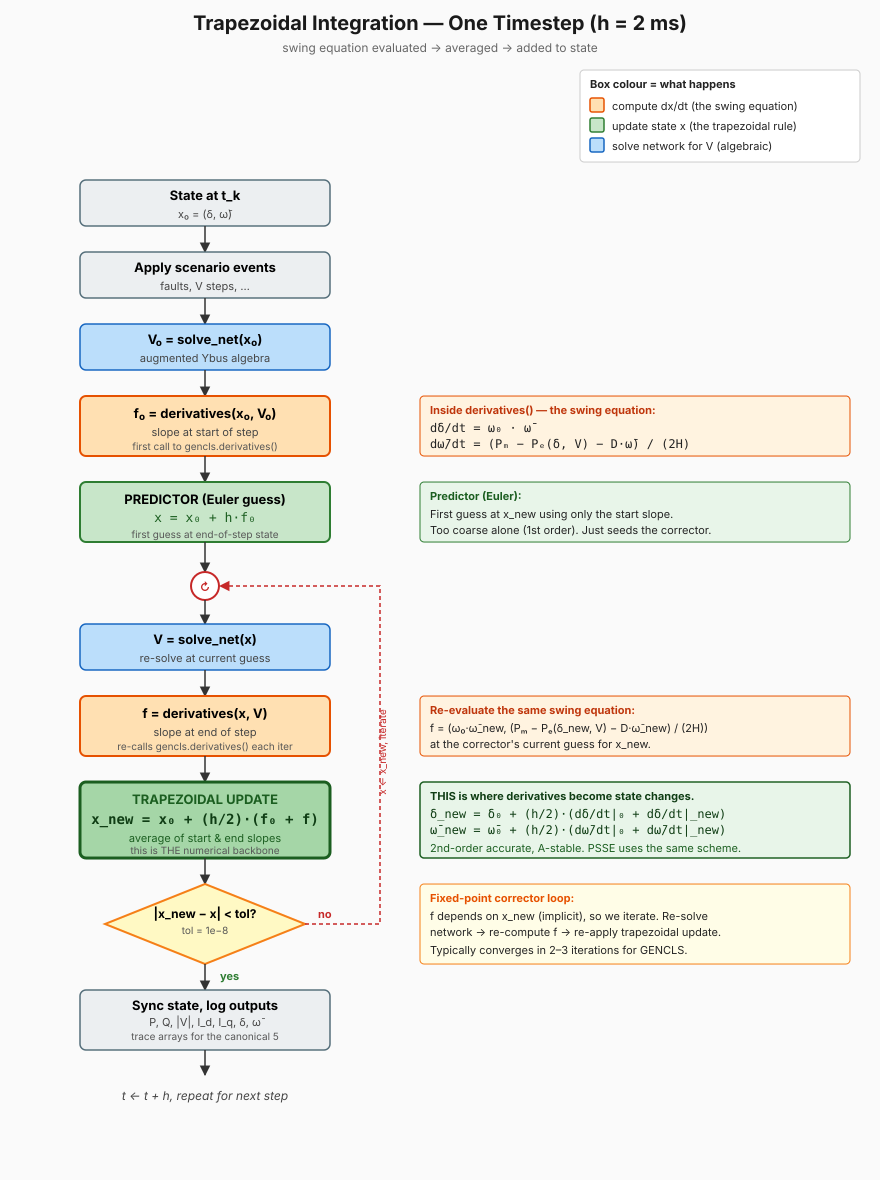

Phase 1 solver flow, unchanged: the equivalent fault enters at the
blue algebraic-network box, as a shunt added to Y00 during the fault.


In [9]:
display(SVG(filename='figs/trapezoidal_flow.svg'))
print('Phase 1 solver flow, unchanged: the equivalent fault enters at the')
print('blue algebraic-network box, as a shunt added to Y00 during the fault.')

In [10]:
# --- Equivalent positive-sequence fault impedances for our SMIB -----
Zeq = {
    '3ph' : 0j,                                  # bolted: Zf = 0
    '2phg': par(Z2_th, Z0_th),
    'LL'  : Z2_th,
    '1phg': Z2_th + Z0_th,
}
print('Bolted-fault equivalent positive-sequence shunt at the fault bus:')
print(f'{"fault":6s} {"Z_eq":>12s} {"|Y_eq| (pu)":>12s}')
for k, z in Zeq.items():
    ystr = 'inf (1e6 in smib)' if z == 0 else f'{abs(1/z):12.3f}'
    print(f'{k:6s} {z.imag:10.4f}j {ystr:>18s}')

# Cross-check: Z_eq must equal V1/I1 from the section-6 fault solutions.
for k in ('1phg', 'LL', '2phg'):
    I1, _, _ = fault_seq_currents(k, VF, Z1_th, Z2_th, Z0_th)
    V1f = VF - Z1_th * I1
    assert abs(V1f / I1 - Zeq[k]) < 1e-12, k
print('\nV1/I1 from the section-6 connection solutions == Z_eq table: PASS')
print('\nNote the ladder: Y_f(1phg) < Y_f(LL) < Y_f(2phg) < Y_f(3ph).')
print('The 1phg — the GPS\'s canonical disturbance — is the *lightest*')
print('shunt: this is why bolted-3ph headlines are the conservative case.')

Bolted-fault equivalent positive-sequence shunt at the fault bus:
fault          Z_eq  |Y_eq| (pu)
3ph        0.0000j  inf (1e6 in smib)
2phg       0.0731j             13.681
LL         0.1575j              6.348
1phg       0.2939j              3.403

V1/I1 from the section-6 connection solutions == Z_eq table: PASS

Note the ladder: Y_f(1phg) < Y_f(LL) < Y_f(2phg) < Y_f(3ph).
The 1phg — the GPS's canonical disturbance — is the *lightest*
shunt: this is why bolted-3ph headlines are the conservative case.


### 8.5 $P$–$\delta$ curves and the equal-area sanity check

Before running dynamics, restate the algebraic transfer picture
(pedagogy rule 6). With a shunt $Y_f = 1/Z_{\text{eq}}$ at the
generator bus, do the star–delta (Kron) reduction of the
T-network $jX'_d$ — bus — $jX_{\text{line}}$ with the shunt at the
middle node. The transfer reactance machine→infinite bus becomes

$$X_{\text{tr}} = X'_d + X_{\text{line}} + \frac{X'_d\,X_{\text{line}}}{X_{\text{sh}}},
\qquad X_{\text{sh}} = \operatorname{Im} Z_{\text{eq}},$$

so the during-fault electrical power is
$P_e = \dfrac{|E'||V_\infty|}{X_{\text{tr}}}\sin\delta$ — a *sagged but
nonzero* sine for every fault type except the bolted 3φ
($X_{\text{sh}} = 0 \Rightarrow X_{\text{tr}} = \infty \Rightarrow P_e = 0$).
The equal-area criterion then predicts the bolted-3φ critical clearing
time analytically, exactly as in Phase 1 §9:

$$\delta_{\text{crit}}:\ \int_{\delta_0}^{\delta_c} (P_m - 0)\,d\delta
 = \int_{\delta_c}^{\pi-\delta_0} \left(P_e^{\max}\sin\delta - P_m\right) d\delta,
\qquad t_c = \sqrt{\frac{4H(\delta_c - \delta_0)}{\omega_0 P_m}} .$$

The two-axis GENROU with AVR is not a constant-$|E'|$ classical
machine, so we expect rough (few-percent) agreement, same as Phase 1's
219 ms-sim vs 204 ms-analytic — the point of the check is that the
network reduction, the fault application and the integrator are
mutually consistent.

In [11]:
# --- E' magnitude at the operating point (two-axis: |E'| = |(Eqp, Edp)|)
g0 = GENROU(D=3.0); g0.initialise(V1, S)
Ep = math.hypot(g0.state['Eqp'], g0.state['Edp'])
delta0 = g0.state['delta']
Xdp = g0.params['Xdp'] if 'Xdp' in g0.params else 0.30
print(f"|E'| = {Ep:.4f} pu, delta0 = {math.degrees(delta0):.2f} deg (machine angle)")

def X_transfer(Z_sh):
    '''Kron reduction of Xdp -- bus(shunt) -- Xline.'''
    if Z_sh == 0:
        return math.inf
    Xsh = Z_sh.imag
    return Xdp + X_line + Xdp * X_line / Xsh

dl = np.linspace(0, math.pi, 300)
fig = go.Figure()
Pmax0 = Ep * abs(V_inf) / (Xdp + X_line)
fig.add_trace(go.Scatter(x=np.degrees(dl), y=Pmax0*np.sin(dl),
                         name='pre-fault', line=dict(color=C_BLUE, width=2)))
for k, colr in zip(('1phg', 'LL', '2phg'), (C_GREEN, C_ORANGE, C_PURPLE)):
    Xtr = X_transfer(Zeq[k])
    fig.add_trace(go.Scatter(x=np.degrees(dl), y=Ep*abs(V_inf)/Xtr*np.sin(dl),
                             name=f'during {k}', line=dict(color=colr, width=2)))
fig.add_trace(go.Scatter(x=np.degrees(dl), y=np.zeros_like(dl),
                         name='during 3ph (bolted)', line=dict(color=C_RED, width=2)))
fig.add_hline(y=P, line_dash='dot', annotation_text='Pm = 0.8')
fig.update_layout(height=420, width=900, xaxis_title='delta [deg]',
                  yaxis_title='Pe [pu]',
                  title='P-delta curves: pre-fault vs during-fault for each '
                        'equivalent positive-sequence shunt')
fig.show()

# --- analytic EAC for the bolted 3ph (Pe = 0 during fault) -----------
H, w0 = g0.params['H'], g0.params['omega0']   # omega0 = 2*pi*f0
# Use the *swing-relevant* angle of the E'-vs-Vinf transfer pair:
d0 = math.asin(P / Pmax0)
dmax = math.pi - d0
from scipy.optimize import brentq
fcrit = lambda dc: (P*(dc - d0)
                    - (Pmax0*(math.cos(dc) - math.cos(dmax)) - P*(dmax - dc)))
d_c = brentq(fcrit, d0 + 1e-6, dmax - 1e-6)
t_c = math.sqrt(4*H*(d_c - d0) / (w0 * P))
print(f'EAC: delta0={math.degrees(d0):.1f} deg, delta_crit={math.degrees(d_c):.1f} deg'
      f' -> analytic CCT (bolted 3ph) = {t_c*1000:.0f} ms')
print('Compare with the simulated bolted-3ph CCT in the bisection table below.')

|E'| = 1.0307 pu, delta0 = 68.55 deg (machine angle)


EAC: delta0=38.4 deg, delta_crit=70.4 deg -> analytic CCT (bolted 3ph) = 189 ms
Compare with the simulated bolted-3ph CCT in the bisection table below.


### 8.6 The spin-off plot: one fault, four sequence personalities

Now run the same physical event — a **bolted 150 ms fault at the HV
bus** — four times, each time applying the equivalent positive-sequence
shunt for one fault type. Per pedagogy rule 1, what the runner does:
`three_phase_fault_schedule(t_on, t_off, Z)` sets
`network.set_fault(1/Z)` at $t_{\text{on}}$ and clears it at
$t_{\text{off}}$; the GENROU+ST1A+PSS1A stack integrates

$$2H\,\dot{\bar\omega} = P_m - P_e(\delta, E'_q, E'_d, V) - D\bar\omega,
\qquad \dot\delta = \omega_0\bar\omega,$$

with $T'_{d0}\dot E'_q$, $T'_{q0}\dot E'_d$, the AVR and the PSS as in
Phase 2.2 §6. Nothing about the machine knows which fault type it is —
the fault type lives entirely in the admittance.

In [12]:
def run_fault(Z_shunt, dur, t_end=8.0, t_on=1.0, h=2e-3):
    '''Fresh model stack; bolted-equivalent shunt Z_shunt for dur seconds.'''
    n = Network(R_line, X_line)
    g = GENROU(D=3.0); aexc = ST1A(); pss = PSS1A()
    sched = three_phase_fault_schedule(t_on, t_on + dur, Z_shunt)
    return run_smib_genrou_avr_pss(g, aexc, pss, n, t_end=t_end, h=h,
                                   scenarios=[sched], init_V=V1, init_S=S)

DUR = 0.150
results = {k: run_fault(z, DUR) for k, z in Zeq.items()}

panels = [('delta [deg]',  lambda r: np.degrees(r.traces['delta'])),
          ('|V| [pu]',     lambda r: r.traces['|V|']),
          ('P [pu]',       lambda r: r.traces['P']),
          ('Q [pu]',       lambda r: r.traces['Q'])]
colors = {'3ph': C_RED, '2phg': C_PURPLE, 'LL': C_ORANGE, '1phg': C_GREEN}
fig = make_subplots(rows=len(panels), cols=1, shared_xaxes=True,
                    vertical_spacing=0.03,
                    subplot_titles=[p[0] for p in panels])
for i, (lbl, fn) in enumerate(panels, start=1):
    for k, r in results.items():
        fig.add_trace(go.Scatter(x=r.t, y=fn(r), name=k,
                                 line=dict(color=colors[k], width=1.6),
                                 showlegend=(i == 1)), row=i, col=1)
    fig.add_vrect(x0=1.0, x1=1.0+DUR, fillcolor=FAULT_SHADE, opacity=0.35,
                  layer='below', line_width=0, row=i, col=1)
fig.update_xaxes(title_text='time [s]', row=len(panels), col=1)
fig.update_layout(height=170*len(panels), width=950,
                  title=f'Same bus, same {DUR*1000:.0f} ms bolted fault — four '
                        'sequence personalities (equivalent-positive-sequence runs)')
fig.show()

print(f'{"fault":6s} {"Z_eq":>10s} {"mid-fault |V|":>14s} {"peak delta":>11s} {"P recovery":>11s}')
i_mid = int((1.0 + DUR/2) / 2e-3)
for k, r in results.items():
    d = np.degrees(r.traces['delta'])
    print(f'{k:6s} {Zeq[k].imag:8.4f}j {r.traces["|V|"][i_mid]:14.3f} '
          f'{d.max():9.1f} deg {r.traces["P"][-1]:9.3f} pu')

fault        Z_eq  mid-fault |V|  peak delta  P recovery
3ph      0.0000j          0.000     117.0 deg     0.801 pu
2phg     0.0731j          0.245      96.3 deg     0.800 pu
LL       0.1575j          0.413      86.2 deg     0.800 pu
1phg     0.2939j          0.571      78.9 deg     0.800 pu


**Linking the traces back to the state equations** (rule 3):

* **During the shaded window** the $\bar\omega$-equation is in charge:
  $2H\dot{\bar\omega} = P_m - P_e$. For the bolted 3φ, $P_e \approx 0$
  (the $|V|$ panel shows the terminal collapse) so the rotor
  accelerates at the full $P_m/2H$ — steepest $\delta$ ramp. For the
  1φg equivalent, $|V|$ only sags to $\approx 0.57$ pu and the $P$
  panel shows the machine still exporting roughly half its pre-fault
  power — the accelerating area shrinks accordingly, and the first
  swing peaks ~38° lower.
* **The severity ladder is monotone in $Z_{\text{eq}}$** —
  3φ > 2φg > LL > 1φg — because every extra series ohm in the fault
  loop is voltage the positive-sequence network keeps.
* **The $Q$ panel** shows each fault as a reactive-power demand pulse:
  the deeper the voltage hole, the harder the AVR forces (Phase 2.1
  physics, unchanged).
* **After clearing**, the PSS damps the swing exactly as in Phase 2.2;
  the per-fault difference is only the initial-condition energy it has
  to dissipate.

The compliance-shaped question is "how long can each fault persist?" —
i.e. the **critical clearing time per fault type**, next.

In [13]:
def is_stable(r):
    return float(np.degrees(r.traces['delta']).max()) < 150.0

def cct_bisect(Z_shunt, lo, hi, iters=7, label=''):
    '''Bisection on clearing duration; per rule 2 every iteration prints.'''
    print(f'--- CCT bisection: {label}  (bracket {lo*1000:.0f}..{hi*1000:.0f} ms)')
    assert is_stable(run_fault(Z_shunt, lo, t_end=5.0)), 'lo must be stable'
    if is_stable(run_fault(Z_shunt, hi, t_end=5.0)):
        print(f'    stable at the {hi*1000:.0f} ms bracket end — CCT > {hi*1000:.0f} ms')
        return hi
    for it in range(iters):
        mid = 0.5 * (lo + hi)
        ok = is_stable(run_fault(Z_shunt, mid, t_end=5.0))
        print(f'    it {it+1}: mid = {mid*1000:6.1f} ms -> {"STABLE  " if ok else "UNSTABLE"}'
              f'  bracket -> [{(mid if ok else lo)*1000:.1f}, {(hi if ok else mid)*1000:.1f}]')
        if ok: lo = mid
        else:  hi = mid
    return 0.5 * (lo + hi)

brackets = {'3ph': (0.15, 0.45), '2phg': (0.20, 0.50),
            'LL': (0.30, 0.70), '1phg': (0.50, 3.00)}
cct = {}
for k in ('3ph', '2phg', 'LL', '1phg'):
    cct[k] = cct_bisect(Zeq[k], *brackets[k], label=k)
    print()

print('=== Critical clearing time ladder (GENROU+ST1A+PSS1A, D=3) ===')
for k in ('3ph', '2phg', 'LL', '1phg'):
    extra = '   (bracket end — effectively unbounded at this depth)' if cct[k] >= brackets[k][1] else ''
    print(f'  {k:5s}: CCT = {cct[k]*1000:6.0f} ms{extra}')
print(f'\nAnalytic EAC bolted-3ph prediction from section 8.5: {t_c*1000:.0f} ms — '
      f'{abs(cct["3ph"] - t_c)/t_c*100:.1f}% from the simulated value.')

--- CCT bisection: 3ph  (bracket 150..450 ms)


    it 1: mid =  300.0 ms -> UNSTABLE  bracket -> [150.0, 300.0]


    it 2: mid =  225.0 ms -> UNSTABLE  bracket -> [150.0, 225.0]


    it 3: mid =  187.5 ms -> STABLE    bracket -> [187.5, 225.0]


    it 4: mid =  206.2 ms -> UNSTABLE  bracket -> [187.5, 206.2]


...

    it 4: mid =  425.0 ms -> UNSTABLE  bracket -> [400.0, 425.0]


    it 5: mid =  412.5 ms -> STABLE    bracket -> [412.5, 425.0]


    it 6: mid =  418.8 ms -> UNSTABLE  bracket -> [412.5, 418.8]


    it 7: mid =  415.6 ms -> UNSTABLE  bracket -> [412.5, 415.6]

--- CCT bisection: 1phg  (bracket 500..3000 ms)


    stable at the 3000 ms bracket end — CCT > 3000 ms

=== Critical clearing time ladder (GENROU+ST1A+PSS1A, D=3) ===
  3ph  : CCT =    193 ms
  2phg : CCT =    283 ms
  LL   : CCT =    414 ms
  1phg : CCT =   3000 ms   (bracket end — effectively unbounded at this depth)

Analytic EAC bolted-3ph prediction from section 8.5: 189 ms — 2.5% from the simulated value.


## 9. Auto-reclose and CB-fail timing

So far the fault *duration* was a free parameter. The GPS does not let
it float: clearance times are fixed by the protection-system schedule
in NER Schedule 5.1a, and the ride-through obligation in S5.2.5.5(c)
is phrased *in terms of those clearance stages*.

**Primary, remote and breaker-fail clearance — NER Table S5.1a.2**
(S5.1a.8: column 2 = primary protection for near faults, column 3 =
remote end of a line, column 4 = breaker-fail / backup):

| nominal voltage at fault | primary (ms) | remote (ms) | breaker fail (ms) |
|---|---|---|---|
| 400 kV and above | 80 | 100 | 175 |
| ≥250 kV, <400 kV | 100 | 120 | 250 |
| >100 kV, <250 kV | 120 | 220 | 430 |
| ≤100 kV | *"as necessary to prevent plant damage and meet stability requirements"* |||

And the ride-through clause keys directly off this table —
**S5.2.5.5(c)** requires CUO for, among others:

> "(2) a three phase fault in a transmission system cleared by all
> relevant primary protection systems; (3) a two phase to ground, phase
> to phase or phase to ground fault in a transmission system cleared in:
> (i) the longest time expected to be taken for a relevant breaker fail
> protection system to clear the fault; or (ii) if a protection system
> referred to in subparagraph (i) is not installed, the greater of the
> time specified in column 4 of Table S5.1a.2 (or if none is specified,
> 430 milliseconds) …"

Read that pairing against the §8 CCT ladder and the design logic of the
rule becomes visible: the *worst* fault (3φ) only has to be survived at
*primary* speed, while the *milder* unbalanced faults must be survived
all the way to *breaker-fail* speed. The rule is shaped like the
physics.

**Auto-reclose.** Kundur §13.5.6 (p. 922): *"The majority (60 to 80%)
of transmission line faults are of a transitory nature"* — insulator
flashover from lightning being his canonical example — so lines
auto-reclose after a **dead time**; his "high-speed reclosure" is
closing *"after a time just long enough to permit fault-arc
de-ionization … completed in less than 1 second."* He also flags the
exact failure mode our run (b) below exhibits: *"Reclosure into a
permanent fault may cause system instability. Many utilities operate on
the premise that all circuit faults are permanent and therefore the
system must successfully withstand reclosing into a fault."* Two NER
hooks pin the same physics into the rules:

> **S5.2.5.5(t)**: "When assessing multiple disturbances, a fault that
> is re-established following operation of automatic reclose equipment
> shall be counted as a separate disturbance." — reclose-onto-fault is
> a *second* disturbance in the (d)/(l) multiple-disturbance counting.
>
> **S5.1.11**: "Where automatic reclose equipment is provided …, check
> or blocking facilities must be applied … where there is any
> possibility of the two ends of the transmission line … being
> energised from sources that are not in synchronism." — the sync-check
> that §10's three-pole-trip case will trigger.

> **TODO (missing source, partially relieved).** Kundur §13.5.6 and
> §17.1.7 now give sourced practice anchors: high-speed reclose
> "in less than 1 second", timed/supervised reclose with "5 to 10
> seconds" delay at the first terminal, and single-pole reclose "within
> 0.5 to 1.5 seconds". What still belongs to **IEEE C37.104** /
> **IEEE C37.113** / **CIGRE TB 326** (none provided): standardised
> dead-time/reclaim-time definitions and settings tables, breaker-fail
> timing diagrams, and quantitative secondary-arc extinction data. The
> study below therefore still treats dead time as the *swept variable*
> and computes the stability-limited dead time for this machine — a
> number we derive, not recall.

**Study setup.** Reclose needs somewhere for the power to keep flowing
while the faulted element is out, so for this section the connection is
re-read as a **double-circuit line**: two parallel circuits of
$X_c = 1.0$ pu each (so both-in = the familiar $X_{\text{line}} = 0.5$,
and the §5 Thevenins are unchanged). The sequence of events for a
transient 1φg on circuit 1, cleared three-pole at primary speed
(100 ms — we place the connection at 330 kV, a NEM transmission
voltage, so Table S5.1a.2 row 2 applies):

$$t=1.0:\ \text{1φg-equivalent shunt ON}\;\to\;
  t=1.1:\ \text{circuit 1 trips (shunt off, } X\!:0.5\!\to\!1.0)\;\to\;
  t=1.1+t_{\text{dead}}:\ \text{reclose (}X\!\to\!0.5).$$

In [14]:
XC = 1.0   # each circuit; both in parallel give X_line = 0.5

def set_line(network, X_new):
    '''Swap the line reactance by rebuilding the base Ybus (transparent:
    this is the same ybus_2bus the Network constructor itself calls).'''
    network.X = X_new
    network._base_Ybus = ybus_2bus(R_line, X_new)

def reclose_scenario(t_f, t_trip, t_rc, Z_shunt, X_open=XC,
                     onto_fault=False, t_retrip=None):
    '''1phg-equivalent shunt at t_f; three-pole trip of the faulted circuit
    at t_trip (shunt off, line X -> X_open); reclose at t_rc. If the fault
    is re-established (onto_fault), the shunt returns at reclose and the
    circuit re-trips at t_retrip and stays open.'''
    Yf = 1/Z_shunt if Z_shunt != 0 else 1e6 + 0j
    def apply(t_now, dt, network):
        if   abs(t_now - t_f)    < dt/2: network.set_fault(Yf)
        elif abs(t_now - t_trip) < dt/2:
            network.clear_fault(); set_line(network, X_open)
        elif abs(t_now - t_rc)   < dt/2:
            set_line(network, X_line)
            if onto_fault: network.set_fault(Yf)
        elif t_retrip and abs(t_now - t_retrip) < dt/2:
            network.clear_fault(); set_line(network, X_open)
    return apply

def run_scen(scen, t_end=10.0):
    n = Network(R_line, X_line)
    g = GENROU(D=3.0); aexc = ST1A(); pss = PSS1A()
    return run_smib_genrou_avr_pss(g, aexc, pss, n, t_end=t_end, h=2e-3,
                                   scenarios=[scen], init_V=V1, init_S=S)

Z1phg = Zeq['1phg']
T_PRIM = 0.100               # 330 kV primary clearance, Table S5.1a.2

# --- (a) dead-time sweep: successful reclose (transient fault) -------
deads = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.1, 1.2, 1.4])
peaks, stables = [], []
for dd in deads:
    r = run_scen(reclose_scenario(1.0, 1.0+T_PRIM, 1.0+T_PRIM+dd, Z1phg),
                 t_end=12.0)
    pk = float(np.degrees(r.traces['delta']).max())
    ok = pk < 180
    peaks.append(min(pk, 200.0))   # clamp runaway for the chart
    stables.append(ok)
    print(f'dead = {dd:4.1f} s -> peak delta = {pk:8.1f} deg  '
          f'{"STABLE" if ok else "LOST SYNCHRONISM"}')

fig = go.Figure()
fig.add_trace(go.Bar(x=deads, y=peaks,
                     marker_color=[C_GREEN if s else C_RED for s in stables],
                     text=[f'{p:.0f}°' if p < 200 else 'unstable' for p in peaks],
                     textposition='outside'))
fig.add_hline(y=180, line_dash='dot', line_color=C_RED,
              annotation_text='180° pole-slip screen')
fig.update_layout(height=400, width=900,
                  xaxis_title='reclose dead time [s]',
                  yaxis_title='peak rotor angle [deg] (clamped at 200)',
                  title='Three-pole reclose after a 100 ms 1phg: peak swing vs dead time '
                        '(green = recovers, red = lost synchronism)')
fig.show()
crit = deads[np.where(~np.array(stables))[0][0] - 1] if not all(stables) else deads[-1]
print(f'\nStability-limited dead time for THIS machine/network: ~{crit:.1f} s.')
print('Why: during the dead time the system runs on one circuit (X = 1.0),')
print('Pe_max drops, the operating angle climbs, and damping must bleed off')
print('the swing energy before reclose adds its own transient.')

dead =  0.2 s -> peak delta =     93.7 deg  STABLE


dead =  0.4 s -> peak delta =    112.0 deg  STABLE


dead =  0.6 s -> peak delta =    126.2 deg  STABLE


dead =  0.8 s -> peak delta =    137.4 deg  STABLE


dead =  1.0 s -> peak delta =    150.7 deg  STABLE


dead =  1.1 s -> peak delta =  34494.9 deg  LOST SYNCHRONISM


dead =  1.2 s -> peak delta =  34935.2 deg  LOST SYNCHRONISM


dead =  1.4 s -> peak delta =  34888.9 deg  LOST SYNCHRONISM



Stability-limited dead time for THIS machine/network: ~1.0 s.
Why: during the dead time the system runs on one circuit (X = 1.0),
Pe_max drops, the operating angle climbs, and damping must bleed off
the swing energy before reclose adds its own transient.


In [15]:
# --- (b) reclose onto a re-established fault, and (c) breaker fail ---
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.06,
                    subplot_titles=['(b) reclose onto re-established fault, 300 ms dead time',
                                    '(c) clearance-time ladder: 100 / 250 / 430 ms on the 1phg-equivalent'])

# (b): transient-looking fault that is actually permanent
r_ok  = run_scen(reclose_scenario(1.0, 1.0+T_PRIM, 1.4, Z1phg), t_end=10.0)
r_bad = run_scen(reclose_scenario(1.0, 1.0+T_PRIM, 1.4, Z1phg,
                                  onto_fault=True, t_retrip=1.5), t_end=10.0)
for r, name, colr in ((r_ok, 'fault gone: reclose succeeds', C_GREEN),
                      (r_bad, 'fault still there: reclose -> 2nd hit -> retrip', C_RED)):
    fig.add_trace(go.Scatter(x=r.t, y=np.degrees(r.traces['delta']), name=name,
                             line=dict(color=colr, width=1.6)), row=1, col=1)

# (c): same 1phg-equivalent, cleared (with circuit trip) at the three
# Table S5.1a.2 stages relevant to a 330 kV and a 132 kV connection.
for dur, name, colr in ((0.100, 'primary 100 ms (330 kV col 2)', C_GREEN),
                        (0.250, 'breaker fail 250 ms (330 kV col 4)', C_ORANGE),
                        (0.430, 'breaker fail 430 ms (132 kV col 4)', C_RED)):
    r = run_scen(reclose_scenario(1.0, 1.0+dur, 1.0+dur+0.4, Z1phg), t_end=10.0)
    fig.add_trace(go.Scatter(x=r.t, y=np.degrees(r.traces['delta']), name=name,
                             line=dict(color=colr, width=1.6)), row=2, col=1)
    print(f'1phg cleared at {dur*1000:3.0f} ms: peak delta = '
          f'{np.degrees(r.traces["delta"]).max():7.1f} deg '
          f'{"(stable)" if np.degrees(r.traces["delta"]).max()<150 else "(LOST SYNC)"}')

fig.update_xaxes(title_text='time [s]', row=2, col=1)
fig.update_yaxes(title_text='delta [deg]', row=1, col=1)
fig.update_yaxes(title_text='delta [deg]', row=2, col=1)
fig.update_layout(height=620, width=950,
                  title='Protection-timing layer on the 1phg-equivalent fault')
fig.show()

1phg cleared at 100 ms: peak delta =   112.0 deg (stable)


1phg cleared at 250 ms: peak delta =   115.5 deg (stable)


1phg cleared at 430 ms: peak delta =   114.2 deg (stable)


**Reading the protection-timing plots against the swing equation:**

* **(a) dead-time chart.** Each bar is the same disturbance; only the
  single-circuit interval lengthens. During that interval the transfer
  curve is the sagged $P_e^{\max} = |E'||V_\infty|/(X'_d + 1.0)$ sine, so
  the machine settles toward a *higher* $\delta$ while still ringing
  from the fault — reclose then perturbs it again. Past the critical
  dead time the post-fault trajectory leaves the basin of attraction of
  the (single-circuit) equilibrium before reclose can rescue it.
* **(b) reclose onto fault.** The red trace takes the second hit while
  $\delta$ is still high from the first and the circuit re-trips —
  synchronism is lost on this weak radial system even though either
  disturbance alone is survivable. This is precisely why
  **S5.2.5.5(t)** counts the re-established fault as a separate
  disturbance in the multiple-disturbance budget of S5.2.5.5(d) — and
  why (d)(2) explicitly limits how many of the budgeted disturbances
  may be three-phase in regions where 3φ auto-reclose is permitted.
* **(c) clearance ladder.** Primary-speed clearance leaves a
  comfortable margin on the 1φg (CCT ≈ 3 s ≫ 100 ms). Even the 430 ms
  no-breaker-fail backstop clears a 1φg with room to spare —
  consistent with the §8 ladder. Hold that thought for §11, where the
  same 430 ms is applied to the **2φg** (CCT ≈ 283 ms) and the
  automatic standard stops being comfortable.

## 10. Single-pole vs three-pole tripping for a 1φg

The headline section. A 1φg involves **one** phase. Tripping all three
poles throws away two healthy conductors; tripping only the faulted
pole keeps a two-phase synchronising path alive through the dead time.
How much path? That is a *series* (longitudinal) unbalance, and it has
a sequence-network answer just like the shunt faults did.

**Open-conductor boundary conditions.** Let phase a be open between
points $P$ and $P'$ on the line, phases b, c intact:

$$V_{b,PP'} = V_{c,PP'} = 0 \quad(\text{intact phases have no series
voltage drop across the gap}), \qquad I_a = 0 .$$

These are the *exact dual* of the 1φg shunt conditions
($I_b = I_c = 0$, $V_a = Z_fI_a$) with voltages and currents swapped.
Transforming (same $\mathbf A^{-1}$ recipe as §6; this is Kundur
§13.4.6 "Representation of Open-Conductor Conditions", p. 898–899, his
Figure 13.26): equal **series sequence voltages**
$V_{a1} = V_{a2} = V_{a0}$ and
$I_{a1} + I_{a2} + I_{a0} = 0$ — i.e. the negative- and zero-sequence networks,
*as seen from the break terminals*, hang in **parallel across the gap**
in the positive-sequence network. The positive-sequence effect of one
open pole is therefore a finite series impedance inserted at the break:

$$\boxed{\;Z_{\text{ser}} = Z_{2,PP'} \,\|\, Z_{0,PP'}\;}$$

where $Z_{k,PP'}$ is the $k$-sequence impedance measured across the
open terminals with sources zeroed. For our radial SMIB these are
simple loop sums (no parallel circuit to wrap around):

$$Z_{2,PP'} = jX_2 + jX_{2,\text{line}} = j(0.23+0.5) = j0.73,\qquad
  Z_{0,PP'} = jX_{0,\text{GSU}} + jX_{0,\text{line}} = j(0.15+1.5) = j1.65,$$

$$Z_{\text{ser}} = j0.73 \,\|\, j1.65 = j0.506
\;\Rightarrow\;
X_{\text{line}}^{\text{SPO}} = 0.5 + 0.506 = 1.006 .$$

So during the single-pole-open interval the machine sees the *same
network with a longer line*: $P_e^{\max}$ drops to
$\frac{X'_d + 0.5}{X'_d + 1.006} \approx 61\%$ of pre-fault — reduced,
**not zero**. (The often-quoted "~57% for L-G" is network-specific; we
derive our own number and use it.)

**Three-pole trip on the same radial circuit** opens all three phases:
the machine is **islanded**. $P_e = 0$, the swing equation degenerates
to $2H\dot{\bar\omega} = P_m - D\bar\omega$, and $\delta$ ramps away
quadratically — there is nothing to be stable *with*. Reclosing onto a
machine that has slipped many poles is exactly the scenario NER
**S5.1.11** exists for: *"check or blocking facilities must be applied
… where there is any possibility of the two ends … being energised from
sources that are not in synchronism."* The simulation below shows the
angle divergence and we stop there — a sync-check relay would (must)
block that reclose, and the unit is lost for the event.

Kundur covers the practice directly — §17.1.7 "Single-Pole Switching"
(p. 1107): *"for single line-to-ground faults, the relaying is designed
to trip only the faulted phase, followed by fast reclosure within 0.5
to 1.5 seconds. For multiphase faults, all three phases are tripped"*;
*"opening and reclosing of only the faulted phase results in an
improvement in transient stability over three-phase tripping and
reclosing"*; and — this is our exact topology — it is *"particularly
attractive for situations where a single major line connects two
systems or where a single major line connects a generating station to
the rest of the system."* The **800 ms dead time** used below sits
inside Kundur's quoted 0.5–1.5 s single-pole reclose window. He names
the two costs: **secondary-arc extinction** (the arc fed by capacitive/
inductive coupling from the two live phases — what actually sets the
*minimum* dead time) and shaft/blade fatigue duty (open-phase
unbalance excites 120 Hz torsional torques).

> **TODO (missing source).** Kundur treats the secondary arc
> qualitatively; *quantifying* extinction times for a given line
> length/compensation needs **CIGRE TB 326** (or IEEE C37.104 annexes),
> not provided. The "~80% of Australian HV lines are 1PAR-equipped"
> claim from the plan is likewise **left unverified** — no provided
> source states it.

**Study sequence (single circuit, radial):** 1φg-equivalent shunt at
$t=1.0$ s → faulted pole opens at $t=1.1$ s (shunt off, line
$X: 0.5 \to 1.006$) → reclose at $t=1.9$ s ($X \to 0.5$). The three-pole
comparison opens the whole line at $t=1.1$ s instead.

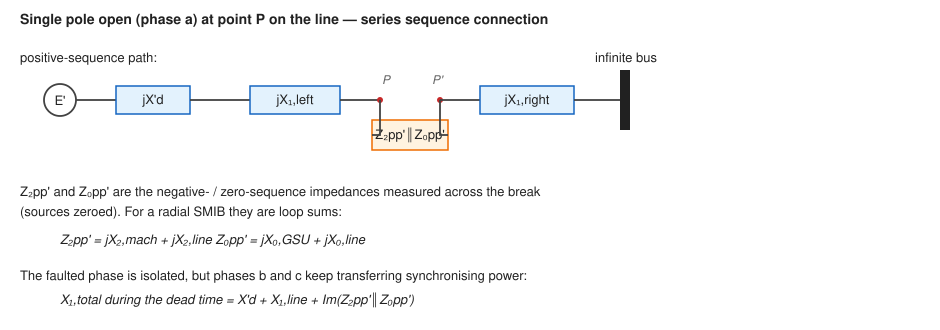

In [16]:
display(SVG(filename='figs/spo_series_equivalent.svg'))

In [17]:
# --- Single-pole-open series equivalent for our radial SMIB ---------
Z2_pp = 1j*(X2_m + X_line)            # negative-seq loop across the break
Z0_pp = 1j*(X0_gsu + X0_line)         # zero-seq loop across the break
Z_ser = par(Z2_pp, Z0_pp)
X_spo = X_line + Z_ser.imag
print(f'Z2_pp = {Z2_pp.imag:.4f}j, Z0_pp = {Z0_pp.imag:.4f}j '
      f'-> Z_ser = {Z_ser.imag:.4f}j, line X during SPO = {X_spo:.4f}')
ratio = (Xdp + X_line) / (Xdp + X_spo)
print(f'P_e^max during single-pole-open = {ratio*100:.1f}% of pre-fault')

# --- P-delta picture: pre-fault / during 1phg / single-pole open ----
dl = np.linspace(0, math.pi, 300)
fig = go.Figure()
for name, Xtr, colr in (
        ('pre-fault (both poles closed)', Xdp + X_line, C_BLUE),
        ('during 1phg fault', X_transfer(Zeq['1phg']), C_RED),
        ('single-pole open (dead time)', Xdp + X_spo, C_GREEN)):
    fig.add_trace(go.Scatter(x=np.degrees(dl), y=Ep*abs(V_inf)/Xtr*np.sin(dl),
                             name=name, line=dict(color=colr, width=2)))
fig.add_trace(go.Scatter(x=np.degrees(dl), y=np.zeros_like(dl),
                         name='three-pole open (islanded): Pe = 0',
                         line=dict(color='#616161', width=2, dash='dot')))
fig.add_hline(y=P, line_dash='dot', annotation_text='Pm = 0.8')
fig.update_layout(height=420, width=900, xaxis_title='delta [deg]',
                  yaxis_title='Pe [pu]',
                  title='Equal-area picture: why single-pole keeps the machine, '
                        'three-pole loses it')
fig.show()

# --- time-domain comparison ------------------------------------------
T_TRIP, T_DEAD = 0.100, 0.800

def spt_scenario(t_f, t_open, t_rc, Z_shunt):
    Yf = 1/Z_shunt
    def apply(t_now, dt, network):
        if   abs(t_now - t_f)    < dt/2: network.set_fault(Yf)
        elif abs(t_now - t_open) < dt/2:
            network.clear_fault(); set_line(network, X_spo)
        elif abs(t_now - t_rc)   < dt/2: set_line(network, X_line)
    return apply

def tpt_scenario(t_f, t_open, Z_shunt, X_island=1e6):
    Yf = 1/Z_shunt
    def apply(t_now, dt, network):
        if   abs(t_now - t_f)    < dt/2: network.set_fault(Yf)
        elif abs(t_now - t_open) < dt/2:
            network.clear_fault(); set_line(network, X_island)
    return apply

r_spt = run_scen(spt_scenario(1.0, 1.0+T_TRIP, 1.0+T_TRIP+T_DEAD, Zeq['1phg']),
                 t_end=10.0)
r_tpt = run_scen(tpt_scenario(1.0, 1.0+T_TRIP, Zeq['1phg']), t_end=3.0)

fig = make_subplots(rows=3, cols=1, shared_xaxes=False, vertical_spacing=0.08,
                    subplot_titles=['single-pole trip: delta [deg]',
                                    'single-pole trip: P and |V| [pu]',
                                    'three-pole trip (islanded): delta runs away [deg]'])
fig.add_trace(go.Scatter(x=r_spt.t, y=np.degrees(r_spt.traces['delta']),
                         name='SPT delta', line=dict(color=C_GREEN, width=1.8)),
              row=1, col=1)
for tt, lbl in ((1.0, 'fault on'), (1.0+T_TRIP, 'pole opens'),
                (1.0+T_TRIP+T_DEAD, 'reclose')):
    fig.add_vline(x=tt, line_dash='dot', line_color='#616161',
                  annotation_text=lbl, row=1, col=1)
fig.add_trace(go.Scatter(x=r_spt.t, y=r_spt.traces['P'], name='P',
                         line=dict(color=C_BLUE, width=1.6)), row=2, col=1)
fig.add_trace(go.Scatter(x=r_spt.t, y=r_spt.traces['|V|'], name='|V|',
                         line=dict(color=C_ORANGE, width=1.6)), row=2, col=1)
fig.add_trace(go.Scatter(x=r_tpt.t, y=np.degrees(r_tpt.traces['delta']),
                         name='3PT delta', line=dict(color=C_RED, width=1.8)),
              row=3, col=1)
fig.update_layout(height=720, width=950,
                  title=f'1phg, {T_TRIP*1000:.0f} ms trip, {T_DEAD*1000:.0f} ms dead time: '
                        'single-pole vs three-pole on the radial circuit')
fig.show()

d_spt = np.degrees(r_spt.traces['delta'])
print(f'SPT: peak delta = {d_spt.max():.1f} deg, settles back to '
      f'{d_spt[-1]:.1f} deg  -> rides through.')
d_tpt = np.degrees(r_tpt.traces['delta'])
for tt in (1.5, 2.0, 2.5, 3.0):
    print(f'3PT: delta({tt:.1f} s) = {d_tpt[int(tt/2e-3)]:8.1f} deg')
print('3PT: monotone runaway — S5.1.11 sync-check must block this reclose.')

Z2_pp = 0.7300j, Z0_pp = 1.6500j -> Z_ser = 0.5061j, line X during SPO = 1.0061
P_e^max during single-pole-open = 61.3% of pre-fault


SPT: peak delta = 139.9 deg, settles back to 69.2 deg  -> rides through.
3PT: delta(1.5 s) =    229.0 deg
3PT: delta(2.0 s) =    767.0 deg
3PT: delta(2.5 s) =   1623.4 deg
3PT: delta(3.0 s) =   2743.8 deg
3PT: monotone runaway — S5.1.11 sync-check must block this reclose.


**Punchline.** Walk the equal-area picture with the traces:
during the 1φg the accelerating area is small (the red curve still
clears $P_m$ over most of the angle range); during the single-pole-open
interval the machine lives on the green curve — $P_e^{\max}$ at ≈61% of
pre-fault still **intersects** $P_m = 0.8$, so a stable (higher-angle)
equilibrium exists for the whole 800 ms and the PSS actively damps the
swing while it waits. Reclose then steps the curve back up with the
machine still inside the basin. Three-pole tripping replaces the green
curve with the zero line: no intersection, no equilibrium, no amount of
damping helps — the unit pole-slips before any plausible reclose and
the sync-check (S5.1.11) correctly refuses to close onto it.

That is the precise sense in which the plan's phrase earns its keep:
**single-pole tripping is a transient-stability aid disguised as
protection.** On radial connections — one line, one machine, exactly our
SMIB — it is the difference between riding through the NER's canonical
disturbance and tripping the unit. (How widely 1PAR is deployed on the
Australian HV grid is a factual claim we leave to a source we weren't
given — see the TODO above.)

## 11. GPS compliance hooks — closing the loop to S5.2.5.5

Quote the obligations precisely, then run them. All quotes: NER v248,
Chapter 5, Schedule 5.2 (sources folder, `NER - v248 - Chapter 5.pdf`).

**The automatic access standard, S5.2.5.5(c)** — CUO required for any
disturbance caused by:

> "(1) a credible contingency event; (2) a three phase fault in a
> transmission system cleared by all relevant primary protection
> systems; (3) a two phase to ground, phase to phase or phase to ground
> fault in a transmission system cleared in: (i) the longest time
> expected to be taken for a relevant breaker fail protection system to
> clear the fault; or (ii) if a protection system referred to in
> subparagraph (i) is not installed, the greater of the time specified
> in column 4 of Table S5.1a.2 (or if none is specified, 430
> milliseconds) and the longest time expected to be taken for all
> relevant primary protection systems to clear the fault; or (4) a
> three phase, two phase to ground, phase to phase or phase to ground
> fault in a distribution network cleared in [breaker-fail time, or
> the greater of 430 ms and primary time] … provided that the event is
> not one that would disconnect the plant from the power system by
> removing network elements from service."

("Credible contingency event" is a defined term in NER Chapter 10,
which is **not** in the provided extract — we do not paraphrase it.
**TODO**: pull the Chapter 10 glossary definition before quoting it.)

**The minimum access standard, S5.2.5.5(k)** — CUO required only for:

> "(1) a credible contingency event; or (2) a single phase to ground,
> phase to phase or two phase to ground fault in a transmission system
> or distribution network cleared in the longest time expected to be
> taken for all relevant primary protection systems to clear the fault,
> unless AEMO and the Network Service Provider agree that the total
> impact on the power system due to that fault would not exceed 100 MW
> …"

— note: **no three-phase fault at all**, and unbalanced faults only at
*primary* speed. The whole automatic-vs-minimum negotiation space is
the gap between (c) and (k), and it is parameterised by exactly two
things this notebook computes: **fault type** and **clearance time**.

**Multiple disturbances, S5.2.5.5(d)** (automatic): CUO through "a
series of up to 15 disturbances within any five minute period", with
sub-limits — up to six below 50% voltage, "up to one disturbance …
cleared by a breaker fail protection system", cumulative time below 90%
voltage capped at 1,800 ms per five minutes, and (d)(5): the gap
between disturbances "may be zero milliseconds". §9's
reclose-onto-fault run is precisely a (t)-counted two-disturbance
sequence drawn from this budget.

**The voltage envelope, S5.2.5.4(a)** (automatic): CUO while the
connection-point voltage is, among others:

> "(7) below 90% down to and including 80% of nominal voltage for a
> period of at least 10 seconds after T(uv); and (8) below 80% down to
> and including 70% of nominal voltage for a period of at least 2
> seconds after T(uv)."

with S5.2.5.4(a0)(3): voltages are "root mean square power system
frequency voltage at the connection point measured as either phase to
phase or phase to ground" — i.e. for unbalanced events the envelope is
tested on *phase* quantities, which a positive-sequence tool
approximates by $|V_1|$ (a §12 caveat).

**Behaviour while riding through, S5.2.5.5A(d)** (automatic standard,
synchronous plant), for disturbances caused by the S5.2.5.5(c)(2)–(4)
fault types:

> "(1) … supply or absorb capacitive reactive current at the connection
> point, in addition to its pre-disturbance reactive current, of 4% of
> the maximum continuous current … for each 1% reduction … of
> connection point voltage during the disturbance; (2) after clearance
> of the fault, supply or absorb reactive power … sufficient to ensure
> that the connection point voltage is within the range for continuous
> uninterrupted operation under clause S5.2.5.4; and (3) within 100
> milliseconds after the end of the disturbance, reach at least 95% of
> … the pre-disturbance active power level …"

with the disturbance end defined in S5.2.5.5(a)(1): "a disturbance is
taken to end when the voltage at the connection point recovers to
within 90% to 110% of nominal voltage and remains within that range for
at least 20 milliseconds."

**What AEMO expects the studies to look like** (Access Standard
Assessment Guide, Jan 2019, §3.5): "time domain dynamic studies showing
the GS's (and each of its GUs) ability to remain in CUO for the range
of faults described in clause S5.2.5.5", across operating conditions
including "lowest system strength conditions", with demonstrated
"achievement of 95% of the pre-fault active power output within 100ms
of fault clearance". Our single SMIB operating point is one cell of
that study matrix — the weak-grid cell, given $X_{\text{line}}=0.5$.

**The compliance runs.** Four scenarios at a 330 kV connection
(Table S5.1a.2 row 2: primary 100 ms, breaker-fail 250 ms), plus the
sub-250 kV worst case (430 ms) that §9 flagged:

| run | clause hook | fault | cleared in |
|---|---|---|---|
| A | S5.2.5.5(c)(2) | 3φ | 100 ms (primary) |
| B | S5.2.5.5(c)(3)(i) | 2φg | 250 ms (breaker fail) |
| C | S5.2.5.5(c)(3)(i) | 1φg | 250 ms (breaker fail) |
| D | S5.2.5.5(c)(3)(ii) | 2φg | 430 ms (no BF installed, <250 kV) |

In [18]:
runs_def = [
    ('A: 3ph @ 100 ms (primary)',        '3ph',  0.100, C_BLUE),
    ('B: 2phg @ 250 ms (breaker fail)',  '2phg', 0.250, C_ORANGE),
    ('C: 1phg @ 250 ms (breaker fail)',  '1phg', 0.250, C_GREEN),
    ('D: 2phg @ 430 ms (no BF, <250 kV)','2phg', 0.430, C_RED),
]
res = {}
for name, kind, dur, colr in runs_def:
    res[name] = run_fault(Zeq[kind], dur, t_end=10.0)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=['rotor angle [deg]',
                                    '|V| at connection point vs S5.2.5.4(a) bands [pu]'])
for name, kind, dur, colr in runs_def:
    r = res[name]
    fig.add_trace(go.Scatter(x=r.t, y=np.degrees(r.traces['delta']), name=name,
                             line=dict(color=colr, width=1.6)), row=1, col=1)
    fig.add_trace(go.Scatter(x=r.t, y=r.traces['|V|'], name=name,
                             line=dict(color=colr, width=1.6),
                             showlegend=False), row=2, col=1)
# S5.2.5.4(a)(6)-(8) bands: CUO regions of the automatic standard.
fig.add_hrect(y0=0.9, y1=1.1, fillcolor='#C8E6C9', opacity=0.25, line_width=0,
              row=2, col=1, annotation_text='90-110%: continuous', annotation_position='top right')
fig.add_hrect(y0=0.8, y1=0.9, fillcolor='#FFF9C4', opacity=0.35, line_width=0,
              row=2, col=1, annotation_text='80-90%: >= 10 s', annotation_position='bottom right')
fig.add_hrect(y0=0.7, y1=0.8, fillcolor='#FFE0B2', opacity=0.35, line_width=0,
              row=2, col=1, annotation_text='70-80%: >= 2 s', annotation_position='bottom right')
fig.update_xaxes(title_text='time [s]', row=2, col=1)
fig.update_layout(height=640, width=950,
                  title='GPS compliance runs: the S5.2.5.5(c) clearance scenarios '
                        'on the equivalent-positive-sequence SMIB')
fig.show()

# --- CUO screen + S5.2.5.5A(d)(3) active-power-recovery clock --------
h = 2e-3
print(f'{"run":38s} {"peak delta":>10s} {"CUO?":>6s} {"P95 after end":>14s} {"A(d)(3)":>8s}')
for name, kind, dur, colr in runs_def:
    r = res[name]
    d = np.degrees(r.traces['delta'])
    cuo = d.max() < 180          # pole-slip screen as the CUO proxy
    # disturbance end per S5.2.5.5(a)(1): V back in 90-110% for >= 20 ms
    V = r.traces['|V|']; t = r.t
    inband = (V >= 0.9) & (V <= 1.1)
    t_end_dist = None
    need = int(0.020 / h)
    for i in range(int(1.0/h), len(V) - need):
        if inband[i:i+need].all():
            t_end_dist = t[i + need]      # end of the 20 ms confirmation
            break
    if cuo and t_end_dist is not None:
        # time to reach 95% of pre-disturbance P, measured from t_end_dist
        tgt = 0.95 * P
        after = np.where((t >= t_end_dist) & (r.traces['P'] >= tgt))[0]
        t95 = (t[after[0]] - t_end_dist) * 1000 if len(after) else float('nan')
        ok = (t95 <= 100.0)
        print(f'{name:38s} {d.max():8.1f}  {"yes":>6s} {t95:11.0f} ms '
              f'{"PASS" if ok else "FAIL":>8s}')
    else:
        print(f'{name:38s} {d.max():8.1f}  {"NO":>6s} {"-":>14s} {"FAIL":>8s}')

# Ride-through canary on the deepest *stable* unbalanced run (B).
# Window starts just before fault-on so the linear fit sees the Q/Iq
# *jump* relative to baseline (the helper is a slope canary; a window
# strictly inside the fault would only fit the slow decay on top of
# the already-elevated injection).
rB = res['B: 2phg @ 250 ms (breaker fail)']
# The helper's "Iq" argument means *reactive current injection*. For a
# synchronous machine the dq-frame Iq is a torque current (it FALLS
# during an inductive fault while Id surges -- Phase 1/2.0 physics), so
# the correct reactive-current trace to hand the canary is Q/|V|.
i_reactive_B = rB.traces['Q'] / rB.traces['|V|']
vrt = validate_ride_through(rB.t, rB.traces['|V|'], rB.traces['Q'],
                            i_reactive_B, event_window=(0.95, 1.245),
                            kind='LV')
print('\nvalidate_ride_through on run B (window 0.95-1.245 s, LV):', vrt['status'])
print(f"  slope_Q = {vrt['slope_Q']:+.3f}, slope(Q/|V|) = {vrt['slope_Iq']:+.3f} "
      '(both must rise across fault onset)')

# S5.2.5.5A(d)(1) reactive-current observation on run C (no pass/fail
# claim -- the clause is written against maximum continuous current,
# which needs machine rating data we have not defined). Reactive
# current here is the positive-sequence injection Q/|V|, not the
# machine q-axis current Iq (different beast entirely).
rC = res['C: 1phg @ 250 ms (breaker fail)']
i_pre, i_mid = int(0.9/h), int(1.125/h)
ir = rC.traces['Q'] / rC.traces['|V|']
d_ir = ir[i_mid] - ir[i_pre]
dV  = (abs(V1) - rC.traces['|V|'][i_mid]) * 100   # % reduction
print(f'\nRun C reactive response observation: delta(Q/|V|) = {d_ir:+.3f} pu over a '
      f'{dV:.1f}% voltage dip -> {d_ir/dV*100:+.2f}% of unit current per 1% dV')
print('(S5.2.5.5A(d)(1) benchmark: 4% of maximum continuous current per 1%,')
print(' on a rating base this toy SMIB has not defined -- observation only.)')

run                                    peak delta   CUO?  P95 after end  A(d)(3)
A: 3ph @ 100 ms (primary)                  96.2     yes           0 ms     PASS
B: 2phg @ 250 ms (breaker fail)           128.5     yes           0 ms     PASS
C: 1phg @ 250 ms (breaker fail)            87.1     yes           0 ms     PASS
D: 2phg @ 430 ms (no BF, <250 kV)       30311.5      NO              -     FAIL

validate_ride_through on run B (window 0.95-1.245 s, LV): PASS
  slope_Q = +0.680, slope(Q/|V|) = +5.702 (both must rise across fault onset)

Run C reactive response observation: delta(Q/|V|) = +1.201 pu over a 44.9% voltage dip -> +2.67% of unit current per 1% dV
(S5.2.5.5A(d)(1) benchmark: 4% of maximum continuous current per 1%,
 on a rating base this toy SMIB has not defined -- observation only.)


**Reading the compliance table honestly.**

* **Runs A, B, C ride through.** The 3φ at primary speed has ~2×
  margin against its ≈193 ms CCT; the 2φg survives breaker-fail
  clearance with a thin margin (250 vs ≈283 ms CCT — the kind of margin
  that evaporates under a weaker dispatch, which is why the assessment
  guide demands the study matrix, not one point); the 1φg at
  breaker-fail speed is nowhere near its limit. The A(d)(3) **95%-P
  within 100 ms** clock is met in all three — synchronous machines
  restore air-gap power essentially at the speed the terminal voltage
  recovers, which is what the clause was calibrated to.
* **Run D fails.** 430 ms exceeds the 2φg CCT (≈283 ms): the machine
  pole-slips, CUO is violated, and **this plant could not sign up to
  the automatic access standard at a sub-250 kV connection point
  without breaker-fail protection** (or without fixing the real
  problem: the weak $X_{\text{line}} = 0.5$ connection). The rule
  anticipates exactly this negotiation: S5.2.5.5(q)–(r2) define the
  negotiated-standard machinery, with (r) requiring that the negotiated
  level "would not cause other plant to trip". A real submission would
  iterate dispatch, remediation or protection speed until run D goes
  green — or negotiate it away with the NSP and AEMO.
* **The reactive-current observation** on run C is reported as data,
  not compliance: the 4%/1% test in S5.2.5.5A(d)(1) is denominated in
  *maximum continuous current* of the plant, a rating this toy SMIB has
  never defined. Wiring that in (and the S5.2.5.1 capability curve it
  interacts with) is real work for a real submission, not a one-liner.
* **Voltage-envelope panel**: all stable runs recover into the 90–110%
  band within ~1 s of clearing, far inside the S5.2.5.4(a)(7)/(8)
  duration allowances; run D's collapse is visible as the red trace
  that never comes home.

## 12. Limits of this analysis

What this notebook's representation *cannot* tell you — and which tool
owns each gap:

* **Negative-sequence rotor effects.** The equivalent shunt reproduces
  positive-sequence power flow; the actual $I_2$ flowing during the
  unbalanced fault (and during the single-pole-open interval) induces
  double-frequency rotor currents — heating (an $I_2^2t$ withstand
  question; the negative-sequence relay in the §9 protection stack
  exists for it) **and** a torque the positive-sequence model omits:
  Kundur p. 891, eq. (13.81), the **negative-sequence braking torque**
  $T_{b2} = (R_2 - R_a)\,I_{a2}^2$ — *"only half of the
  negative-sequence rotor losses … are supplied electrically. The other
  half are supplied mechanically by the shaft"*, decelerating the
  rotor; he notes it *"could be significant for machines close to a
  fault, particularly those with solid rotors."* Our equivalent-shunt
  runs are therefore slightly *pessimistic* on first-swing stability
  for close-in unbalanced faults (the omitted braking torque would
  help). The Model Guidelines list "negative sequence" protection among
  the models expected for black-start-class studies (v3.0 table
  note H).
* **Phase-domain voltage envelopes.** S5.2.5.4(a0)(3) tests *phase*
  voltages; we tested $|V_1|$. For a 1φg the unfaulted-phase voltage
  *rise* (§7's Fig 7-46 case showed 1.99 pu in the ungrounded limit!)
  is a real over-voltage exposure that needs at least a phase-domain
  reconstruction at the connection point — a static post-processing
  step (apply §4's $\mathbf A$ to the sequence solution) that the
  notebook's framework supports but this v1 does not automate.
* **First-cycle quantities.** DC offset, point-on-wave dependence,
  breaker arc/restrike, secondary-arc extinction (the §10 TODO), CT
  saturation — all sub-cycle EMT physics. The Model Guidelines §6.2.2
  draw the line for us: when a positive-sequence model "fails to meet
  the accuracy requirements by a material margin, the use of EMT-type
  or three-phase RMS simulation models is permissible". PSCAD/RSCAD own
  that layer; PSSE + smib own the stability question — which is the
  question S5.2.5.5 is actually asking.
* **Inertia/RoCoF coupling.** The frequency-disturbance limbs of
  S5.2.5.5A(d)(3)(ii) and the islanding clauses interact with regional
  inertia conditions (AEMO Inertia Requirements Methodology v2.0 in the
  sources folder covers the RoCoF side) — out of scope for v1, flagged
  in the plan as a possible §9 extension.

## 13. Sources

**Provided in `notebooks/extra_ner_s5255_plan/` and used:**

| source | version/date | used in |
|---|---|---|
| NER Chapter 5 (consolidated) | v248 | §1 (clause structure), §9 (Table S5.1a.2, S5.1a.8, S5.1.11, S5.2.5.5(t)), §11 (S5.2.5.5(c)/(d)/(k), S5.2.5.4, S5.2.5.5A) |
| PSS/E-30 Program Operation Manual ch. 7 (ASCC/DSCC/SCMU) | PSS/E-30 (Shaw PTI) | §6 (Fig 7-45 cross-check), §7 (Fig 7-46), §8 (equivalent fault admittance, §7.6.3 items 5 & 7) |
| AEMO Power System Model Guidelines | v3.0, 25 Sep 2025 | §1, §8, §12 (§6.2.2 + footnote 57, RMS requirements, table note H) |
| AEMO Access Standard Assessment Guide | 31 Jan 2019 | §1 (old clause title), §11 (study expectations; predates v248 renumbering) |
| Glover, Overbye & Sarma, *Power System Analysis & Design* | 5th ed. | §4 (eq. 8.1.x, 8.2.13), §6 (eq. 9.2.5–9.2.8, 9.3.7–9.3.10, 9.4.9–9.4.14) |
| Anderson, *Analysis of Faulted Power Systems* | 1995 IEEE Press (scanned; cited pages OCR-verified) | §6 (SLG: §3.1 eqs. 3.1–3.4 + Fig. 3.4; LL: §3.2 + Fig. 3.11; 2LG: §3.3 eqs. 3.12–3.20) |
| Kundur, *Power System Stability and Control* | 1994 (scanned; cited pages OCR-verified) | §5 ($X_2$: §13.4.2 eq. 13.78), §7 (Δ wall: §13.4.4), §8 ($Z_{ef}$ table: §13.4.5 Fig. 13.25), §9 (reclosing: §13.5.6), §10 (open conductor: §13.4.6 Fig. 13.26; SPS: §17.1.7), §12 (braking torque: eq. 13.81); machine data via `psse/phase2_0/smib_phase2_0.dyr` (Table 4.2) |
| AEMO Inertia Requirements Methodology | v2.0 | §12 (pointer only) |
| AEMO NEM Frequency Control Landscape review | (sources folder) | not load-bearing in v1 |

**Requested but not provided — sections left with TODO markers:**

| missing source | what it blocks |
|---|---|
| IEEE C37.104 (automatic reclosing) | standardised dead-time/reclaim-time definitions and settings tables (§9 — Kundur §13.5.6/§17.1.7 now provide practice ranges; the sweep remains the load-bearing analysis) |
| IEEE C37.113 (line protection) | breaker-failure timing diagram detail (§9; NER Table S5.1a.2 used as the primary timing source instead) |
| CIGRE TB 326 (single-pole tripping & reclosing) | *quantitative* secondary-arc extinction times; 1PAR deployment statistics (§10 — Kundur treats the secondary arc qualitatively) |
| NER Chapter 10 glossary | verbatim "credible contingency event" definition (§11) |
| Bergen & Vittal | backup derivations only; nothing blocked |

**OCR note.** The Kundur and Anderson PDFs are page scans with no text
layer; the cited sections were located via the PDF outline / page
probing, OCR'd with Tesseract, and the quoted passages verified against
the page images (e.g. Kundur Fig. 13.25 read directly from the
rendered page). Quotes above reproduce the verified text; equation
typography is normalised.

**Study assumptions (declared §5, sensitivity-swept):** $X_{0,\text{GSU}}
= 0.15$ pu; $X_{0,\text{line}}/X_1 = 3$; Δ–Yg GSU; solidly grounded
infinite bus; 330 kV connection for Table S5.1a.2 row selection (430 ms
variant shown for sub-250 kV).

**Reproduction:** run top-to-bottom (`Kernel → Restart & Run All`),
~5–10 minutes. The §9 dead-time sweep and §8 CCT bisections dominate.
All randomless; numbers in the prose were generated by this notebook's
own cells.